In [23]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# lesson - 2 ( Mathematical building blocks )

In [14]:
from tensorflow.keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [15]:
train_images.shape

(60000, 28, 28)

In [16]:
len(train_labels)

60000

In [17]:
train_labels

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [18]:
test_images.shape

(10000, 28, 28)

In [19]:
len(test_labels)

10000

In [20]:
test_labels

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [10]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

In [12]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [2]:
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255

In [14]:
model.fit(train_images, train_labels, epochs=5, batch_size=128)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9245 - loss: 0.2672
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9686 - loss: 0.1080
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9793 - loss: 0.0692
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9849 - loss: 0.0503
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9898 - loss: 0.0366


In [19]:
test_digits = test_images[0:10]
predictions = model.predict(test_digits)
predictions[5]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


array([3.9627650e-08, 9.9945897e-01, 2.9112095e-06, 4.4200144e-07,
       1.1345866e-05, 1.8003112e-08, 5.4568673e-08, 5.1938300e-04,
       6.4784167e-06, 4.0265724e-07], dtype=float32)

In [20]:
predictions[5].argmax()

1

In [22]:
predictions[5][1]

0.99945897

In [23]:
test_labels[5]

1

In [24]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"Test_acc : {test_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9803 - loss: 0.0642
Test_acc : 0.9803000092506409


In [39]:
# scalar - rank 0 tensors
import numpy as np
x = np.array(12)
print(f"scaler output: {x}")
print(f"scalar axis: {x.ndim}\n") # --> ndim is used to diaplay no of axis of numpy tensor.

# Vectors - rank 1 tensors
x1 = np.array([12, 6, 5, 14, 7])
print(f"vector output: {x1}")
print(f"vector axis: {x1.ndim}\n")

# Matrices - rank 2 tensors
x2 = np.array([[5, 78, 2, 34, 0],
             [6, 79, 3, 35, 1],
             [7, 80, 4, 36, 2]])
print(f"matrices output: {x2}")
print(f"matrices axis: {x2.ndim}\n")

# rank 3 & higher tensors
x3 = np.array([[[5, 78, 2, 34, 0],
               [6, 79, 3, 35, 1],
               [7, 80, 4, 36, 2]],
              [[5, 78, 2, 34, 0],
               [6, 79, 3, 35, 1],
               [7, 80, 4, 36, 2]],
              [[5, 78, 2, 34, 0],
               [6, 79, 3, 35, 1],
               [7, 80, 4, 36, 2]]])
print(f"three higher output: {x3}")
print(f"three higher axis: {x3.ndim}\n")

scaler output: 12
scalar axis: 0

vector output: [12  6  5 14  7]
vector axis: 1

matrices output: [[ 5 78  2 34  0]
 [ 6 79  3 35  1]
 [ 7 80  4 36  2]]
matrices axis: 2

three higher output: [[[ 5 78  2 34  0]
  [ 6 79  3 35  1]
  [ 7 80  4 36  2]]

 [[ 5 78  2 34  0]
  [ 6 79  3 35  1]
  [ 7 80  4 36  2]]

 [[ 5 78  2 34  0]
  [ 6 79  3 35  1]
  [ 7 80  4 36  2]]]
three higher axis: 3



In [43]:
train_images.ndim

3

In [44]:
train_images.dtype

dtype('uint8')

In [ ]:
import matplotlib.pyplot as plt

digit = train_images[5]
plt.imshow(digit, cmap=plt.cm.binary)
plt.show()

In [51]:
train_labels[5]

2

In [21]:
my_slices = train_images[10:100]
my_slices.shape

(90, 28, 28)

In [22]:
my_slice = train_images[:, 14:, 14:]
my_slice.shape

(60000, 14, 14)

In [23]:
my_slice = train_images[:, 7:-7, 7:-7]
my_slice.shape

(60000, 14, 14)

In [24]:
batch = train_images[:128]
batch

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [34]:
import numpy as np
import time

x = np.random.random((20, 100))
y = np.random.random((20, 100))

z = x + y
z = np.maximum(z, 0.)

t0 = time.time()
for _ in range(1000):
    z = x + y
    z = np.maximum(z, 0.)
print("Took: {0:.2f} sec".format(time.time() - t0))

Took: 0.01 sec


In [39]:
def naive_relu(x):
    assert len(x.shape) == 2 
    x = x.copy()  
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            x[i, j] = max(x[i, j], 0)

def naive_add(x, y):
    assert len(x.shape) == 2 
    assert x.shape == y.shape
    x = x.copy() 
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            x[i, j] += y[i, j]
    return x

t0 = time.time()
for _ in range(1000):
    z = naive_add(x, y)
    z = naive_relu(z)
print("Took: {0:.2f} sec".format(time.time() - t0))

Took: 1.85 sec


In [8]:
import numpy as np

x = np.random.random((32, 10))
y = np.random.random((10, ))
print(f"x{x}")
print(f"y{y}")

x[[0.55786619 0.80153682 0.98220634 0.02065192 0.86497449 0.58999635
  0.98881081 0.76370896 0.6608836  0.83112775]
 [0.12278903 0.19915716 0.38198421 0.6809828  0.48287629 0.84925912
  0.25487015 0.83691888 0.56227709 0.19110538]
 [0.49195277 0.49831128 0.33166802 0.33576001 0.66487067 0.9503714
  0.26731955 0.66664105 0.78112783 0.73597758]
 [0.63869139 0.17115146 0.17952866 0.91548725 0.77941882 0.21664588
  0.62540167 0.72434584 0.897053   0.77347382]
 [0.06853861 0.37089871 0.71110889 0.36708197 0.91595657 0.79341041
  0.81026293 0.63356415 0.24874002 0.76438375]
 [0.65028835 0.56132042 0.87929739 0.28370109 0.30013585 0.53177886
  0.6936969  0.60983007 0.02603369 0.03336097]
 [0.35657869 0.47616281 0.8534959  0.43209337 0.11133015 0.66045735
  0.24901776 0.6536731  0.43946395 0.95879065]
 [0.64469175 0.50234532 0.0386318  0.36594434 0.11472581 0.61349521
  0.67972121 0.85955576 0.65387792 0.31247868]
 [0.89474199 0.98246165 0.73372623 0.1500389  0.48746003 0.50500789
  0.72806964

In [9]:
y = np.expand_dims(y, axis=0)
print(f"y --- > {y}")

y --- > [[0.41131829 0.65342811 0.17105039 0.24024341 0.60310455 0.18907907
  0.99970227 0.48391303 0.94906462 0.70268233]]


In [10]:
y = np.concatenate( [y] * 32, axis=0)
print(f"y --- > {y}")

y --- > [[0.41131829 0.65342811 0.17105039 0.24024341 0.60310455 0.18907907
  0.99970227 0.48391303 0.94906462 0.70268233]
 [0.41131829 0.65342811 0.17105039 0.24024341 0.60310455 0.18907907
  0.99970227 0.48391303 0.94906462 0.70268233]
 [0.41131829 0.65342811 0.17105039 0.24024341 0.60310455 0.18907907
  0.99970227 0.48391303 0.94906462 0.70268233]
 [0.41131829 0.65342811 0.17105039 0.24024341 0.60310455 0.18907907
  0.99970227 0.48391303 0.94906462 0.70268233]
 [0.41131829 0.65342811 0.17105039 0.24024341 0.60310455 0.18907907
  0.99970227 0.48391303 0.94906462 0.70268233]
 [0.41131829 0.65342811 0.17105039 0.24024341 0.60310455 0.18907907
  0.99970227 0.48391303 0.94906462 0.70268233]
 [0.41131829 0.65342811 0.17105039 0.24024341 0.60310455 0.18907907
  0.99970227 0.48391303 0.94906462 0.70268233]
 [0.41131829 0.65342811 0.17105039 0.24024341 0.60310455 0.18907907
  0.99970227 0.48391303 0.94906462 0.70268233]
 [0.41131829 0.65342811 0.17105039 0.24024341 0.60310455 0.18907907
  0.

In [11]:
def naive_add_matrix_and_vector(x,y):
    assert len(x.shape) == 2
    assert len(y.shape) == 1
    assert x.shape[1] == y.shape[0]
    x = x.copy()
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            x[i, j] += y[j]
    return x

In [12]:
import numpy as np

x = np.array([[1, 2, 3],
              [4, 5, 6]])
y = np.array([10, 20, 30])

result = naive_add_matrix_and_vector(x, y)
print(result)

[[11 22 33]
 [14 25 36]]


In [15]:
import numpy as np
x = np.random.random((64, 3, 32, 10))
y = np.random.random((32, 10))
z = np.maximum(x , y)

print(x.shape)
print(y.shape)
print(z.shape)

(64, 3, 32, 10)
(32, 10)
(64, 3, 32, 10)


In [17]:
x = np.array([[0., 1.],
             [2., 3.],
             [4., 5.]])
print(x.shape)

(3, 2)


In [20]:
x = x.reshape((6, 1))
x

array([[0.],
       [1.],
       [2.],
       [3.],
       [4.],
       [5.]])

In [21]:
x = x.reshape((2, 3))
x

array([[0., 1., 2.],
       [3., 4., 5.]])

In [22]:
x = np.zeros((300 , 20))
x = np.transpose(x)
x.shape

(20, 300)

In [2]:
import tensorflow as tf

x = tf.Variable(0.)
with tf.GradientTape() as tape:
    y = 2 * x + 3
grad_of_y_wrt_x = tape.gradient(y, x)

In [4]:
from tensorflow.keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255

In [7]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

In [8]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [9]:
model.fit(train_images, train_labels, epochs=5, batch_size=128)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9252 - loss: 0.2667
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9687 - loss: 0.1082
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9796 - loss: 0.0700
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9851 - loss: 0.0505
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9894 - loss: 0.0368


# lesson - 3 ( Introduction to Keras and TensorFlow )

In [1]:
import tensorflow as tf

x = tf.ones(shape=(2, 1))
print(x)

tf.Tensor(
[[1.]
 [1.]], shape=(2, 1), dtype=float32)


In [2]:
x = tf.zeros(shape=(2, 1))
print(x)

tf.Tensor(
[[0.]
 [0.]], shape=(2, 1), dtype=float32)


In [3]:
x = tf.random.normal(shape=(3, 1), mean=0., stddev=1.)
print(x)

tf.Tensor(
[[-0.6857515 ]
 [ 0.33543116]
 [ 1.5306861 ]], shape=(3, 1), dtype=float32)


In [4]:
x = tf.random.uniform(shape=(3, 1), minval=0., maxval=1.)
print(x)

tf.Tensor(
[[0.3419354 ]
 [0.6365547 ]
 [0.31494057]], shape=(3, 1), dtype=float32)


In [5]:
import numpy as np

x = np.ones(shape=(2, 2))
x[0, 1] = 0
print(x)

x1 = tf.ones(shape=(2, 1))
x1[0, 0] = 0
print(x1)

[[1. 0.]
 [1. 1.]]


TypeError: 'tensorflow.python.framework.ops.EagerTensor' object does not support item assignment

In [6]:
v = tf.Variable(initial_value=tf.random.normal(shape=(3, 1)))
print(v)

<tf.Variable 'Variable:0' shape=(3, 1) dtype=float32, numpy=
array([[-1.0150552],
       [-1.060062 ],
       [-0.7962165]], dtype=float32)>


In [7]:
v.assign(tf.ones((3, 1)))
v[0, 0].assign(3.)

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[3.],
       [1.],
       [1.]], dtype=float32)>

In [8]:
import tensorflow as tf
import numpy as np

num_samples_per_class = 1000

negative_samples = np.random.multivariate_normal(
    mean = [0, 3],
    cov = [[1, 0.5], [0.5, 1]],
    size = num_samples_per_class)

positive_samples = np.random.multivariate_normal(
    mean = [3, 0],
    cov = [[1, 0.5], [0.5, 1]],
    size = num_samples_per_class)

inputs = np.vstack((negative_samples, positive_samples)).astype(np.float32)

targets = np.vstack((np.zeros((num_samples_per_class, 1), dtype="float32"),
                     np.ones((num_samples_per_class, 1), dtype="float32")))

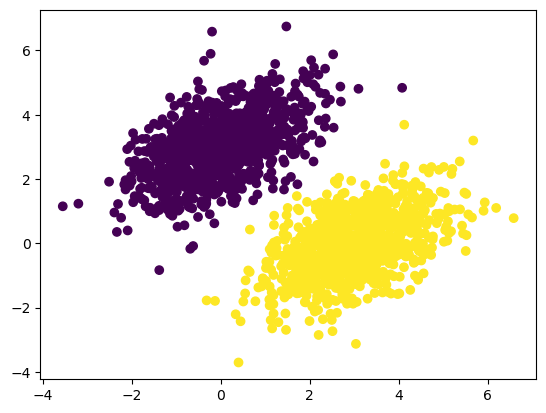

In [9]:
import matplotlib.pyplot as plt

plt.scatter(inputs[:, 0], inputs[:, 1], c=targets[:, 0])
plt.show()

In [10]:
input_dim = 2
output_dim = 1

w = tf.Variable(initial_value=tf.random.uniform(shape=(input_dim, output_dim)))
b = tf.Variable(initial_value=tf.zeros(shape=(output_dim,)))

In [11]:
def model(inputs):
    return tf.matmul(inputs, w) + b

In [12]:
def square_loss(targets, predictions):
    per_sample_losses = tf.square(targets - predictions)
    return tf.reduce_mean(per_sample_losses)

In [13]:
learning_rate = 0.1

def training_step(inputs, targets):
    with tf.GradientTape() as tape:
        predictions = model(inputs)
        loss = square_loss(predictions, targets)
    grad_loss_wrt_w, grad_loss_wrt_b = tape.gradient(loss, [w, b])
    w.assign_sub(grad_loss_wrt_w * learning_rate)
    b.assign_sub(grad_loss_wrt_b * learning_rate)
    return loss

In [14]:
for step in range(40):
    loss = training_step(inputs, targets)
    print(f"Loss at Step {step} : {loss:.4f}")

Loss at Step 0 : 2.1348
Loss at Step 1 : 0.3386
Loss at Step 2 : 0.1461
Loss at Step 3 : 0.1165
Loss at Step 4 : 0.1063
Loss at Step 5 : 0.0989
Loss at Step 6 : 0.0923
Loss at Step 7 : 0.0863
Loss at Step 8 : 0.0809
Loss at Step 9 : 0.0759
Loss at Step 10 : 0.0714
Loss at Step 11 : 0.0673
Loss at Step 12 : 0.0635
Loss at Step 13 : 0.0600
Loss at Step 14 : 0.0569
Loss at Step 15 : 0.0540
Loss at Step 16 : 0.0514
Loss at Step 17 : 0.0490
Loss at Step 18 : 0.0468
Loss at Step 19 : 0.0448
Loss at Step 20 : 0.0430
Loss at Step 21 : 0.0414
Loss at Step 22 : 0.0398
Loss at Step 23 : 0.0385
Loss at Step 24 : 0.0372
Loss at Step 25 : 0.0361
Loss at Step 26 : 0.0350
Loss at Step 27 : 0.0340
Loss at Step 28 : 0.0332
Loss at Step 29 : 0.0324
Loss at Step 30 : 0.0316
Loss at Step 31 : 0.0310
Loss at Step 32 : 0.0304
Loss at Step 33 : 0.0298
Loss at Step 34 : 0.0293
Loss at Step 35 : 0.0288
Loss at Step 36 : 0.0284
Loss at Step 37 : 0.0280
Loss at Step 38 : 0.0277
Loss at Step 39 : 0.0274


In [ ]:
predictions = model(inputs)
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)
plt.show()

In [ ]:
x = np.linspace(-1, 4, 100)
y = - w[0] / w[1] * x + (0.5 - b) / w[1]
plt.plot(x,y, "-r")
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)
plt.show()

## Lesson-4 (Classification and Regression)

In [17]:
from tensorflow.keras.datasets import imdb

In [18]:
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(
    num_words=10000)

In [25]:
max([max(sequence) for sequence in train_data])

9999

In [29]:
word_index = imdb.get_word_index()
reverse_word_index = dict(
    [(value, key) for (key, value) in word_index.items()] )
decoded_review =" ".join(
    [reverse_word_index.get(i - 3, "?") for i in train_data[0] ])
decoded_review

"? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you th

In [32]:
import numpy as np

def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        for j in sequence:
            results[i, j] = 1
    return results

x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

y_train = np.asarray(train_labels).astype("float32")
y_test = np.asarray(test_labels).astype("float32")

x_train[0]
y_train[0]

array([0., 1., 1., ..., 0., 0., 0.])

1.0

In [36]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])


In [37]:
model.compile(optimizer="rmsprop",
      loss="binary_crossentropy",
      metrics=["accuracy"])

In [38]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.7511 - loss: 0.5702 - val_accuracy: 0.8209 - val_loss: 0.4665
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8848 - loss: 0.3722 - val_accuracy: 0.8788 - val_loss: 0.3466
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9136 - loss: 0.2752 - val_accuracy: 0.8879 - val_loss: 0.2978
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9303 - loss: 0.2194 - val_accuracy: 0.8655 - val_loss: 0.3264
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9406 - loss: 0.1830 - val_accuracy: 0.8878 - val_loss: 0.2801
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9517 - loss: 0.1551 - val_accuracy: 0.8863 - val_loss: 0.2846
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9590 - loss: 0.1333 - val_accuracy: 0.8872 - val_loss: 0.2887
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9651 - loss: 0.1160 - val_accuracy: 0.8773 - v

In [40]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

Text(0.5, 0, 'Epochs')

Text(0, 0.5, 'Loss')

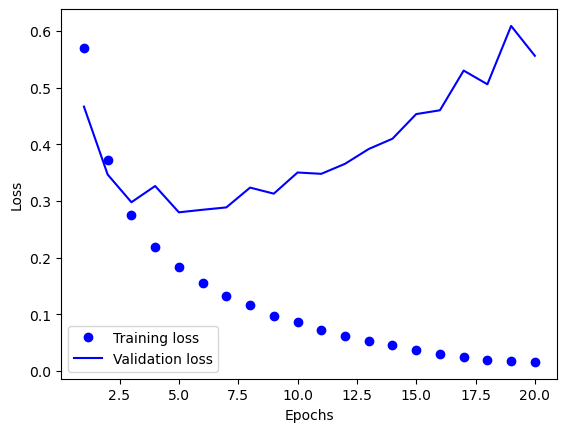

In [43]:
import matplotlib.pyplot as plt

history_dict = history.history
loss_value = history_dict["loss"]
val_loss_value = history_dict["val_loss"]
epochs = range(1, len(loss_value) + 1)
plt.plot(epochs, loss_value, "bo", label="Training loss")
plt.plot(epochs, val_loss_value, "b", label="Validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

Text(0.5, 1.0, 'Training and validation accuracy')

Text(0.5, 0, 'Epochs')

Text(0, 0.5, 'Accuracy')

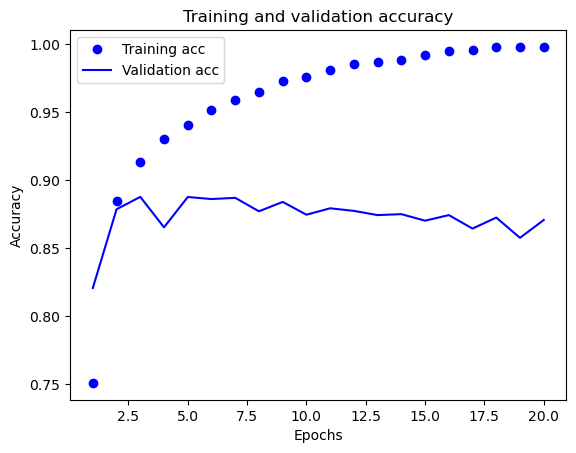

In [44]:
plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
plt.plot(epochs, acc, "bo", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [3]:
from tensorflow.keras.datasets import reuters

(train_data, train_labels), (test_data, test_labels) = reuters.load_data(num_words = 10000)

In [4]:
len(train_data)

8982

In [5]:
len(test_data)

2246

In [6]:
train_data[10]

[1,
 245,
 273,
 207,
 156,
 53,
 74,
 160,
 26,
 14,
 46,
 296,
 26,
 39,
 74,
 2979,
 3554,
 14,
 46,
 4689,
 4329,
 86,
 61,
 3499,
 4795,
 14,
 61,
 451,
 4329,
 17,
 12]

In [10]:
word_index = reuters.get_word_index()
reverse_word_index = dict(
    [(value, key) for (key, value) in word_index.items()])
decoded_newswire = " ".join(
    [reverse_word_index.get(i - 3, "?") for i in train_data[10]])

In [11]:
decoded_newswire

'? period ended december 31 shr profit 11 cts vs loss 24 cts net profit 224 271 vs loss 511 349 revs 7 258 688 vs 7 200 349 reuter 3'

In [12]:
train_labels[10]

3

In [13]:
import numpy as np

def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        for j in sequence:
            results[i, j] = 1
    return results

x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(train_data)

In [14]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)

In [15]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(46, activation="softmax")
])

In [16]:
model.compile(optimizer="rmsprop",
      loss="categorical_crossentropy",
      metrics=["accuracy"])

In [18]:
x_val = x_train[:1000]
partial_x_train = x_train[1000:]
y_val = y_train[:1000]
partial_y_train = y_train[1000:]

history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.4726 - loss: 2.6908 - val_accuracy: 0.6240 - val_loss: 1.7937
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6903 - loss: 1.4939 - val_accuracy: 0.7040 - val_loss: 1.3262
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7573 - loss: 1.1329 - val_accuracy: 0.7460 - val_loss: 1.1410
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7987 - loss: 0.9234 - val_accuracy: 0.7720 - val_loss: 1.0524
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8338 - loss: 0.7726 - val_accuracy: 0.7770 - val_loss: 0.9786
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8659 - loss: 0.6427 - val_accuracy: 0.8000 - val_loss: 0.9359
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8840 - loss: 0.5452 - val_accuracy: 0.8120 - val_loss: 0.8885
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9048 - loss: 0.4552 - val_accuracy: 0.8090 - v

C:\Users\ISMAIMZ\AppData\Local\Temp\ipykernel_13584\1667861400.py:7: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo" (-> color='b'). The keyword argument will take precedence.
  plt.plot(epochs, loss_value, "bo", label="Training loss", color="darkblue")
C:\Users\ISMAIMZ\AppData\Local\Temp\ipykernel_13584\1667861400.py:8: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, val_loss_value, "b", label="Validation loss", color="darkblue")


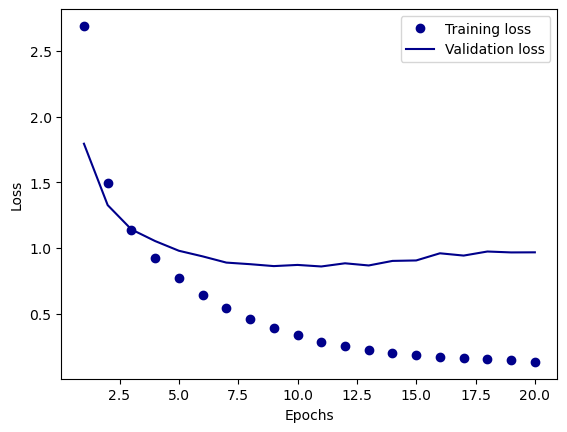

In [19]:
import matplotlib.pyplot as plt

history_dict = history.history
loss_value = history_dict["loss"]
val_loss_value = history_dict["val_loss"]
epochs = range(1, len(loss_value) + 1)
plt.plot(epochs, loss_value, "bo", label="Training loss", color="darkblue")
plt.plot(epochs, val_loss_value, "b", label="Validation loss", color="darkblue")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

C:\Users\ISMAIMZ\AppData\Local\Temp\ipykernel_13584\3391501497.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo" (-> color='b'). The keyword argument will take precedence.
  plt.plot(epochs, acc, "bo", label="Training acc", color="darkblue")
C:\Users\ISMAIMZ\AppData\Local\Temp\ipykernel_13584\3391501497.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, val_acc, "b", label="Validation acc", color="darkblue")


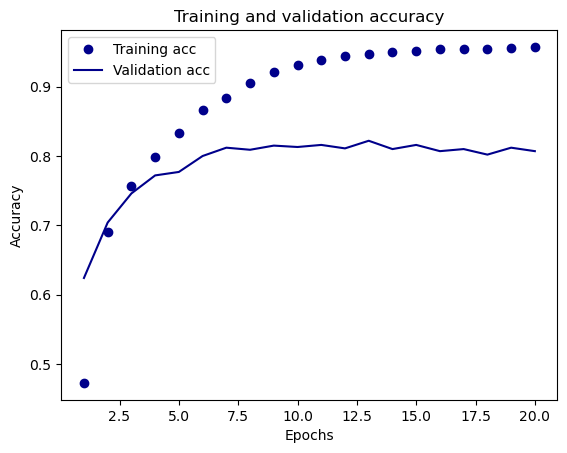

In [20]:
plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
plt.plot(epochs, acc, "bo", label="Training acc", color="darkblue")
plt.plot(epochs, val_acc, "b", label="Validation acc", color="darkblue")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [21]:
predictions = model.predict(x_test)

281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [22]:
predictions[0].shape

(46,)

In [24]:
from tensorflow.keras.datasets import boston_housing

(train_data, train_targets), (test_data, test_targets) = boston_housing.load_data()

In [25]:
print(train_data.shape)
print(test_data.shape)

(404, 13)
(102, 13)


In [26]:
print(train_targets)
print(test_targets)

[15.2 42.3 50.  21.1 17.7 18.5 11.3 15.6 15.6 14.4 12.1 17.9 23.1 19.9
 15.7  8.8 50.  22.5 24.1 27.5 10.9 30.8 32.9 24.  18.5 13.3 22.9 34.7
 16.6 17.5 22.3 16.1 14.9 23.1 34.9 25.  13.9 13.1 20.4 20.  15.2 24.7
 22.2 16.7 12.7 15.6 18.4 21.  30.1 15.1 18.7  9.6 31.5 24.8 19.1 22.
 14.5 11.  32.  29.4 20.3 24.4 14.6 19.5 14.1 14.3 15.6 10.5  6.3 19.3
 19.3 13.4 36.4 17.8 13.5 16.5  8.3 14.3 16.  13.4 28.6 43.5 20.2 22.
 23.  20.7 12.5 48.5 14.6 13.4 23.7 50.  21.7 39.8 38.7 22.2 34.9 22.5
 31.1 28.7 46.  41.7 21.  26.6 15.  24.4 13.3 21.2 11.7 21.7 19.4 50.
 22.8 19.7 24.7 36.2 14.2 18.9 18.3 20.6 24.6 18.2  8.7 44.  10.4 13.2
 21.2 37.  30.7 22.9 20.  19.3 31.7 32.  23.1 18.8 10.9 50.  19.6  5.
 14.4 19.8 13.8 19.6 23.9 24.5 25.  19.9 17.2 24.6 13.5 26.6 21.4 11.9
 22.6 19.6  8.5 23.7 23.1 22.4 20.5 23.6 18.4 35.2 23.1 27.9 20.6 23.7
 28.  13.6 27.1 23.6 20.6 18.2 21.7 17.1  8.4 25.3 13.8 22.2 18.4 20.7
 31.6 30.5 20.3  8.8 19.2 19.4 23.1 23.  14.8 48.8 22.6 33.4 21.1 13.6
 32.2 13.1

In [27]:
mean = train_data.mean(axis=0)
train_data -= mean
std = train_data.std(axis=0)
train_data /= std
test_data -= mean
test_data /= std

In [28]:
def build_model():
    model = keras.Sequential([
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(1)
    ])
    model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
    return model

In [29]:
k = 4 
num_val_samples = len(train_data) // k
num_epochs = 100
all_scores = []
for i in range(k):
    print(f"Processing fold #{i}")
    val_data = train_data[i * num_val_samples: (i +1) * num_val_samples]
    val_targets = train_targets[i * num_val_samples: (i + 1) * num_val_samples]
    partial_train_data = np.concatenate(
    [train_data[:i * num_val_samples],
    train_data[(i + 1) * num_val_samples:]], axis=0)
    partial_train_targets = np.concatenate(
    [train_targets[:i * num_val_samples],
    train_targets[(i + 1) * num_val_samples:]], axis=0)
    model = build_model()
    model.fit(partial_train_data, partial_train_targets, epochs=num_epochs, batch_size=16, verbose=0)
    val_mse, val_mae = model.evaluate(val_data, val_targets, verbose=0)
    all_scores.append(val_mae)

Processing fold #0
Processing fold #1
Processing fold #2
Processing fold #3


In [30]:
all_scores

[2.1620798110961914, 2.507101058959961, 2.5592029094696045, 2.3710131645202637]

In [31]:
np.mean(all_scores)

2.399849236011505

In [36]:
num_epochs = 500 
all_mae_histories = [] 
for i in range(k):
    print(f"Processing fold #{i}")
    val_data = train_data[i * num_val_samples: (i + 1) * num_val_samples] 
    val_targets = train_targets[i * num_val_samples: (i + 1) * num_val_samples]
    partial_train_data = np.concatenate(   
        [train_data[:i * num_val_samples],
         train_data[(i + 1) * num_val_samples:]],
        axis=0)
    partial_train_targets = np.concatenate(
        [train_targets[:i * num_val_samples],
         train_targets[(i + 1) * num_val_samples:]],
        axis=0)
    model = build_model()      
    history = model.fit(partial_train_data, partial_train_targets,   
                validation_data=(val_data, val_targets),
                epochs=num_epochs, batch_size=16, verbose=0)
    mae_history = history.history["val_mae"]
    all_mae_histories.append(mae_history)

Processing fold #0
Processing fold #1
Processing fold #2
Processing fold #3


In [37]:
average_mae_history = [
    np.mean([x[i] for x in all_mae_histories]) for i in range(num_epochs)]

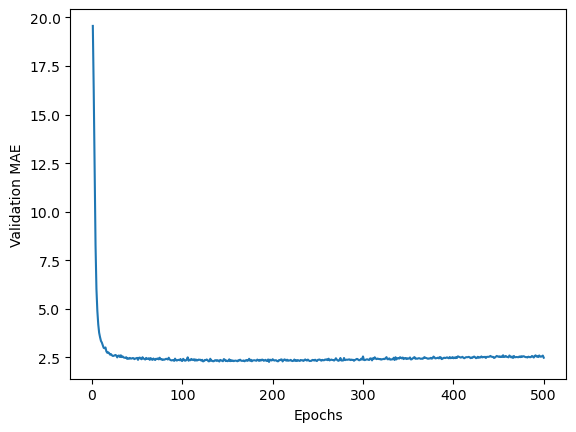

In [39]:
plt.plot(range(1, len(average_mae_history) + 1), average_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.show()

In [40]:
predictions = model.predict(test_data)
predictions[0]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


array([10.300581], dtype=float32)

## Lesson-5 (Fundamentals of machine learning)

In [42]:
from tensorflow.keras.datasets import mnist
import numpy as np

(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

train_images_with_noise_channels = np.concatenate(
    [train_images, np.random.random((len(train_images), 784))], axis=1)

train_images_with_zeros_channels = np.concatenate(
    [train_images, np.zeros((len(train_images), 784))], axis=1)

In [43]:
from tensorflow import keras
from tensorflow.keras import layers

def get_model():
    model = keras.Sequential([
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    model.compile(optimizer="rmsprop", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

model = get_model()
history_noise = model.fit(
    train_images_with_noise_channels, train_labels,
    epochs = 10,
    batch_size = 128,
    validation_split = 0.2)

model = get_model()
history_zeros = model.fit(
    train_images_with_zeros_channels, train_labels,
    epochs = 10,
    batch_size = 128,
    validation_split = 0.2)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8123 - loss: 0.6112 - val_accuracy: 0.9023 - val_loss: 0.3098
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9213 - loss: 0.2551 - val_accuracy: 0.9448 - val_loss: 0.1829
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9480 - loss: 0.1702 - val_accuracy: 0.9474 - val_loss: 0.1759
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9620 - loss: 0.1217 - val_accuracy: 0.9515 - val_loss: 0.1516
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9731 - loss: 0.0883 - val_accuracy: 0.9626 - val_loss: 0.1274
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9786 - loss: 0.0662 - val_accuracy: 0.9656 - val_loss: 0.1174
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9846 - loss: 0.0482 - val_accuracy: 0.9553 - val_loss: 0.1727
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9883 - loss: 0.0357 - val_accur

In [ ]:
import matplotlib.pyplot as plt

val_acc_noise = history_noise.history["val_accuracy"]
val_acc_zeros = history_zeros.history["val_accuracy"]
epochs = range(1, 11)
plt.plot(epochs, val_acc_noise, "b-",
 label="Validation accuracy with noise channels")
plt.plot(epochs, val_acc_zeros, "b--",
 label="Validation accuracy with zeros channels")
plt.title("Effect of noise channels on validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

In [3]:
from tensorflow.keras.datasets import mnist
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers

(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.compile(optimizer=keras.optimizers.RMSprop(1.), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.fit(train_images, train_labels, epochs=10, batch_size=128, validation_split=0.2)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.3533 - loss: 835.6015 - val_accuracy: 0.2227 - val_loss: 2.2502
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.2183 - loss: 2.7185 - val_accuracy: 0.1607 - val_loss: 2.3342
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.2029 - loss: 2.5678 - val_accuracy: 0.2379 - val_loss: 2.4875
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.1940 - loss: 2.5560 - val_accuracy: 0.1915 - val_loss: 2.4058
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.2008 - loss: 2.4203 - val_accuracy: 0.1816 - val_loss: 2.2792
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.1887 - loss: 2.5355 - val_accuracy: 0.2060 - val_loss: 2.1178
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.1938 - loss: 2.3249 - val_accuracy: 0.1858 - val_loss: 2.2134
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1788 - loss: 2.3380 - val_accuracy: 

In [5]:
from tensorflow.keras.datasets import mnist
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers

(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.compile(optimizer=keras.optimizers.RMSprop(1e-2), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history = model.fit(train_images, train_labels, epochs=10, batch_size=128, validation_split=0.2)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9105 - loss: 0.3651 - val_accuracy: 0.9630 - val_loss: 0.1348
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9649 - loss: 0.1260 - val_accuracy: 0.9629 - val_loss: 0.1397
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9739 - loss: 0.0990 - val_accuracy: 0.9663 - val_loss: 0.1359
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9797 - loss: 0.0778 - val_accuracy: 0.9733 - val_loss: 0.1308
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9830 - loss: 0.0713 - val_accuracy: 0.9730 - val_loss: 0.1607
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9846 - loss: 0.0585 - val_accuracy: 0.9706 - val_loss: 0.1804
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9869 - loss: 0.0533 - val_accuracy: 0.9711 - val_loss: 0.2021
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9891 - loss: 0.0450 - val_accuracy: 0.

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8331 - loss: 0.6703 - val_accuracy: 0.9050 - val_loss: 0.3593
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9023 - loss: 0.3525 - val_accuracy: 0.9138 - val_loss: 0.3103
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9112 - loss: 0.3176 - val_accuracy: 0.9182 - val_loss: 0.2942
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9151 - loss: 0.3016 - val_accuracy: 0.9194 - val_loss: 0.2854
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9183 - loss: 0.2919 - val_accuracy: 0.9237 - val_loss: 0.2776
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9199 - loss: 0.2853 - val_accuracy: 0.9250 - val_loss: 0.2769
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9211 - loss: 0.2806 - val_accuracy: 0.9254 - val_loss: 0.2724
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9227 - loss: 0.2765 - val_accuracy: 0.

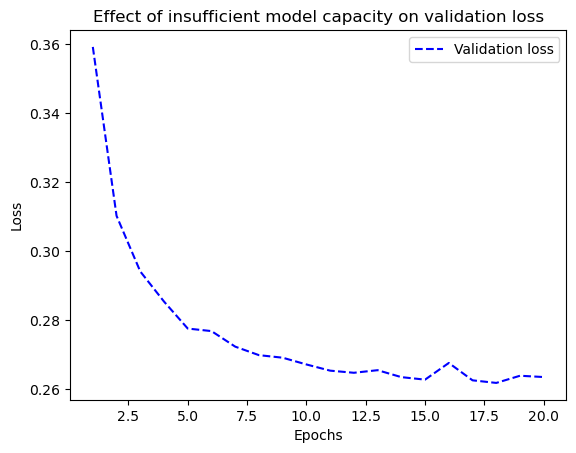

In [8]:
model = keras.Sequential([layers.Dense(10, activation="softmax")])
model.compile(optimizer="rmsprop",
      loss="sparse_categorical_crossentropy",
      metrics=["accuracy"])
history_small_model = model.fit(
    train_images, train_labels,
    epochs=20,
    batch_size=128,
    validation_split=0.2)

import matplotlib.pyplot as plt
val_loss = history_small_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b--",
 label="Validation loss")
plt.title("Effect of insufficient model capacity on validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8999 - loss: 0.3541 - val_accuracy: 0.9467 - val_loss: 0.1894
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9535 - loss: 0.1587 - val_accuracy: 0.9572 - val_loss: 0.1422
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9663 - loss: 0.1122 - val_accuracy: 0.9653 - val_loss: 0.1161
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9744 - loss: 0.0861 - val_accuracy: 0.9693 - val_loss: 0.1037
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9799 - loss: 0.0685 - val_accuracy: 0.9658 - val_loss: 0.1143
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9831 - loss: 0.0563 - val_accuracy: 0.9724 - val_loss: 0.0949
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9860 - loss: 0.0475 - val_accuracy: 0.9698 - val_loss: 0.1034
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9880 - loss: 0.0390 - val_accuracy: 0.

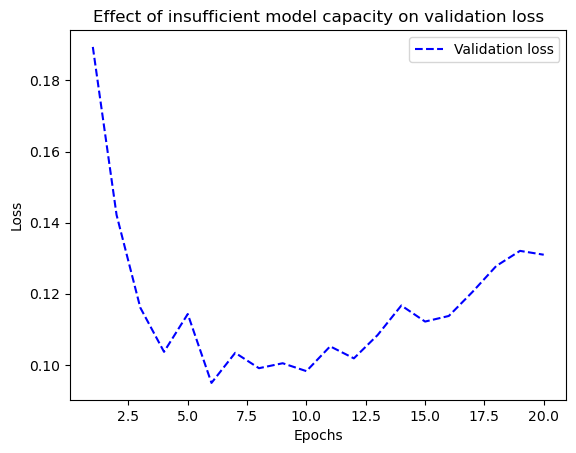

In [9]:
model = keras.Sequential([
    layers.Dense(96, activation="relu"),
    layers.Dense(96, activation="relu"),
    layers.Dense(10, activation="softmax"),
])
model.compile(optimizer="rmsprop",
      loss="sparse_categorical_crossentropy",
      metrics=["accuracy"])
history_large_model = model.fit(
    train_images, train_labels,
    epochs=20,
    batch_size=128,
    validation_split=0.2)

val_loss = history_large_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b--",
 label="Validation loss")
plt.title("Effect of insufficient model capacity on validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

In [11]:
from tensorflow.keras.datasets import imdb
(train_data, train_labels), _ = imdb.load_data(num_words=10000)

def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1
    return results

train_data = vectorize_sequences(train_data)

In [12]:
model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
history_original = model.fit(train_data, train_labels, epochs=20, batch_size=512, validation_split=0.4)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.7731 - loss: 0.5501 - val_accuracy: 0.8590 - val_loss: 0.4205
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8881 - loss: 0.3456 - val_accuracy: 0.8534 - val_loss: 0.3577
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9129 - loss: 0.2601 - val_accuracy: 0.8855 - val_loss: 0.2963
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9279 - loss: 0.2118 - val_accuracy: 0.8678 - val_loss: 0.3210
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9395 - loss: 0.1791 - val_accuracy: 0.8851 - val_loss: 0.2802
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9497 - loss: 0.1528 - val_accuracy: 0.8856 - val_loss: 0.2868
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9575 - loss: 0.1315 - val_accuracy: 0.8863 - val_loss: 0.2928
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9619 - loss: 0.1171 - val_accuracy: 0.8844 - v

In [13]:
model = keras.Sequential([
    layers.Dense(4, activation="relu"),
    layers.Dense(4, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
history_smaller_model = model.fit(train_data, train_labels, epochs=20, batch_size=512, validation_split=0.4)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7727 - loss: 0.6008 - val_accuracy: 0.8489 - val_loss: 0.5210
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8775 - loss: 0.4596 - val_accuracy: 0.8740 - val_loss: 0.4274
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8997 - loss: 0.3700 - val_accuracy: 0.8814 - val_loss: 0.3695
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9145 - loss: 0.3068 - val_accuracy: 0.8855 - val_loss: 0.3295
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9259 - loss: 0.2588 - val_accuracy: 0.8877 - val_loss: 0.3038
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9345 - loss: 0.2213 - val_accuracy: 0.8896 - val_loss: 0.2817
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9419 - loss: 0.1881 - val_accuracy: 0.8894 - val_loss: 0.2743
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9497 - loss: 0.1630 - val_accuracy: 0.8894 - v

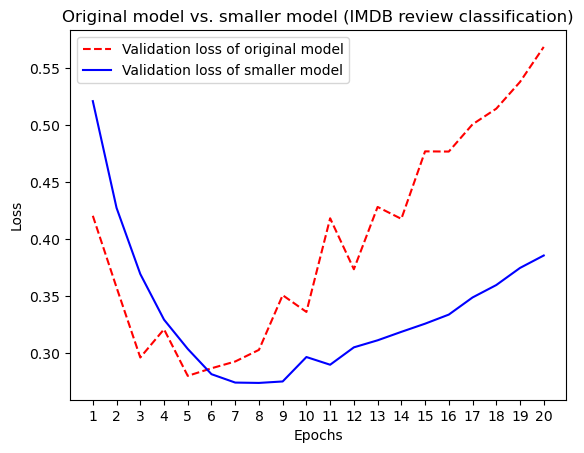

In [15]:
original_val_loss = history_original.history["val_loss"]
smaller_model_val_loss = history_smaller_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    smaller_model_val_loss,
    "b-",
    label="Validation loss of smaller model",
)
plt.title("Original model vs. smaller model (IMDB review classification)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

In [16]:
model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(512, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
history_larger_model = model.fit(train_data, train_labels, epochs=20, batch_size=512, validation_split=0.4)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - accuracy: 0.7207 - loss: 0.5648 - val_accuracy: 0.8574 - val_loss: 0.3544
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - accuracy: 0.8661 - loss: 0.3266 - val_accuracy: 0.8797 - val_loss: 0.2908
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - accuracy: 0.9049 - loss: 0.2384 - val_accuracy: 0.8920 - val_loss: 0.2682
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - accuracy: 0.9321 - loss: 0.1750 - val_accuracy: 0.8841 - val_loss: 0.2932
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - accuracy: 0.9470 - loss: 0.1437 - val_accuracy: 0.8597 - val_loss: 0.3836
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - accuracy: 0.9626 - loss: 0.1063 - val_accuracy: 0.8882 - val_loss: 0.3249
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - accuracy: 0.9762 - loss: 0.0784 - val_accuracy: 0.8807 - val_loss: 0.3704
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.9793 - loss: 0.0674 - val_accuracy: 0.8855 - 

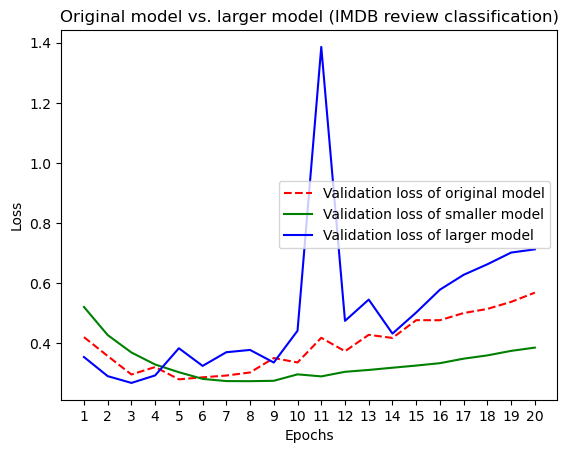

In [20]:
original_val_loss = history_original.history["val_loss"]
smaller_model_val_loss = history_smaller_model.history["val_loss"]
larger_model_val_loss = history_larger_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)

plt.plot(
    epochs,
    smaller_model_val_loss,
    "g-",
    label="Validation loss of smaller model",
)

plt.plot(
    epochs,
    larger_model_val_loss,
    "b-",
    label="Validation loss of larger model",
)
plt.title("Original model vs. larger model (IMDB review classification)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

# Lesson-6 ( The Universal workflow of Mechine Learning ) - Theory

# Lesson-7 ( Working with Keras a Deep Dive )

In [1]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

In [2]:
model = keras.Sequential()
model.add(layers.Dense(64, activation="relu"))
model.add(layers.Dense(10, activation="softmax"))

In [3]:
model = keras.Sequential(name="my_example_model")
model.add(layers.Dense(64, activation="relu", name="my_first_layer"))
model.add(layers.Dense(10, activation="softmax", name="my_last_layer"))
model.build((None, 3))
model.summary()

Model: "my_example_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ my_first_layer (Dense)          │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_last_layer (Dense)           │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
model = keras.Sequential()
model.add(keras.Input(shape=(3,)))
model.add(layers.Dense(64, activation="relu"))

In [5]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           256 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 256 (1.00 KB)

 Trainable params: 256 (1.00 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.add(layers.Dense(10, activation="softmax"))
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
inputs = keras.Input(shape=(3,), name="my_input")
features = layers.Dense(64, activation="relu")(inputs)
outputs = layers.Dense(10, activation="softmax")(features)
model = keras.Model(inputs=inputs, outputs=outputs)

In [8]:
print(inputs.shape)
print(inputs.dtype)

(None, 3)
float32


In [9]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ my_input (InputLayer)           │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
vocabulary_size = 10000
num_tags = 100
num_departments = 4

title = keras.Input(shape=(vocabulary_size,), name="title")
text_body = keras.Input(shape=(vocabulary_size,), name="text_body")
tags = keras.Input(shape=(num_tags,), name="tags")

features = layers.Concatenate()([title, text_body, tags])
features = layers.Dense(64, activation="relu")(features)

priority = layers.Dense(1, activation="sigmoid", name="priority")(features)
department = layers.Dense(
    num_departments, activation="softmax", name="department")(features)

model = keras.Model(inputs=[title, text_body, tags],
                    outputs=[priority, department])

In [12]:
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ title (InputLayer)  │ (None, 10000)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_body           │ (None, 10000)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tags (InputLayer)   │ (None, 100)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 20100)     │          0 │ title[0][0],      │
│ (Concatenate)       │                   │            │ text_body[0][0],  │
│                     │                   │            │ tags[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 64)        │  1,286,464 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ priority (Dense)    │ (None, 1)         │         65 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ department (Dense)  │ (None, 4)         │        260 │ dense_8[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,286,789 (4.91 MB)

 Trainable params: 1,286,789 (4.91 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
import numpy as np

num_samples = 1280

title_data = np.random.randint(0, 2, size=(num_samples, vocabulary_size))
text_body_data = np.random.randint(0, 2, size=(num_samples, vocabulary_size))
tags_data = np.random.randint(0, 2, size=(num_samples, num_tags))

priority_data = np.random.random(size=(num_samples, 1))
department_data = np.random.randint(0, 2, size=(num_samples, num_departments))

model.compile(optimizer="rmsprop", loss=["mean_squared_error", "categorical_crossentropy"], metrics=[["mean_absolute_error"], ["accuracy"]])
model.fit([title_data, text_body_data, tags_data], [priority_data, department_data], epochs=1)

model.evaluate([title_data, text_body_data, tags_data], [priority_data, department_data])

priority_preds, department_preds = model.predict([title_data, text_body_data, tags_data])

40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - department_accuracy: 0.2617 - department_loss: 24.5728 - loss: 24.8911 - priority_loss: 0.3184 - priority_mean_absolute_error: 0.4872
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - department_accuracy: 0.1086 - department_loss: 26.1247 - loss: 26.4578 - priority_loss: 0.3331 - priority_mean_absolute_error: 0.5024
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [14]:
model.compile(optimizer="rmsprop",
              loss={"priority": "mean_squared_error", "department":
                    "categorical_crossentropy"},
              metrics={"priority": ["mean_absolute_error"], "department":
                       ["accuracy"]})
model.fit({"title": title_data, "text_body": text_body_data,
           "tags": tags_data},
          {"priority": priority_data, "department": department_data},
          epochs=1)
model.evaluate({"title": title_data, "text_body": text_body_data,
                "tags": tags_data},
               {"priority": priority_data, "department": department_data})
priority_preds, department_preds = model.predict(
    {"title": title_data, "text_body": text_body_data, "tags": tags_data})

40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - department_accuracy: 0.2695 - department_loss: 18.7651 - loss: 19.0982 - priority_loss: 0.3331 - priority_mean_absolute_error: 0.5024
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - department_accuracy: 0.2703 - department_loss: 12.3635 - loss: 12.6966 - priority_loss: 0.3331 - priority_mean_absolute_error: 0.5024
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [16]:
model.layers

[<InputLayer name=title, built=True>,
 <InputLayer name=text_body, built=True>,
 <InputLayer name=tags, built=True>,
 <Concatenate name=concatenate, built=True>,
 <Dense name=dense_8, built=True>,
 <Dense name=priority, built=True>,
 <Dense name=department, built=True>]

In [19]:
model.layers[2].output

<KerasTensor shape=(None, 100), dtype=float32, sparse=False, ragged=False, name=tags>

In [21]:
class CustomerTicketModel(keras.Model):

    def __init__(self, num_departments):
        super().__init__()
        self.concat_layer = layers.Concatenate()
        self.mixing_layer = layers.Dense(64, activation="relu")
        self.priority_scorer = layers.Dense(1, activation="sigmoid")
        self.department_classifier = layers.Dense(
            num_departments, activation="softmax")

    def call(self, inputs):
        title = inputs["title"]
        text_body = inputs["text_body"]
        tags = inputs["tags"]

        features = self.concat_layer([title, text_body, tags])
        features = self.mixing_layer(features)
        priority = self.priority_scorer(features)
        department = self.department_classifier(features)
        return priority, department

In [22]:
model = CustomerTicketModel(num_departments=4)

priority, department = model(
    {"title": title_data, "text_body": text_body_data, "tags": tags_data})

In [23]:
model.compile(optimizer="rmsprop",
              loss=["mean_squared_error", "categorical_crossentropy"],  
              metrics=[["mean_absolute_error"], ["accuracy"]]) 

model.fit({"title": title_data,           
           "text_body": text_body_data,   
           "tags": tags_data},            
          [priority_data, department_data],    
          epochs=1)

model.evaluate({"title": title_data,
                "text_body": text_body_data,
                "tags": tags_data},
               [priority_data, department_data])
priority_preds, department_preds = model.predict({"title": title_data, "text_body": text_body_data,
                                                  "tags": tags_data})

40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.2445 - categorical_crossentropy_loss: 26.1136 - loss: 26.4313 - mean_absolute_error: 0.4871 - mean_squared_error_loss: 0.3177
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4273 - categorical_crossentropy_loss: 14.2277 - loss: 14.5608 - mean_absolute_error: 0.5024 - mean_squared_error_loss: 0.3331
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [1]:
from tensorflow.keras.datasets import mnist


def get_mnist_model():            
    inputs = keras.Input(shape=(28 * 28,))
    features = layers.Dense(512, activation="relu")(inputs)
    features = layers.Dropout(0.5)(features)
    outputs = layers.Dense(10, activation="softmax")(features)
    model = keras.Model(inputs, outputs)
    return model

(images, labels), (test_images, test_labels) = mnist.load_data()    
images = images.reshape((60000, 28 * 28)).astype("float32") / 255 
test_images = test_images.reshape((10000, 28 * 28)).astype("float32") / 255 
train_images, val_images = images[10000:], images[:10000]
train_labels, val_labels = labels[10000:], labels[:10000]

In [4]:
from tensorflow import keras
from tensorflow.keras import layers

model = get_mnist_model()

model.compile(optimizer="rmsprop", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.fit(train_images, train_labels, epochs=3, validation_data=(val_images, val_labels))
test_metrics = model.evaluate(test_images, test_labels)
predictions = model.predict(test_images)

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9127 - loss: 0.2955 - val_accuracy: 0.9591 - val_loss: 0.1424
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9540 - loss: 0.1582 - val_accuracy: 0.9671 - val_loss: 0.1185
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9632 - loss: 0.1297 - val_accuracy: 0.9711 - val_loss: 0.1035
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9736 - loss: 0.0935
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
%load_ext tensorboard
%tensorboard --logdir logs


model = get_mnist_model()

model.compile(optimizer="rmsprop", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

tensorboard = keras.callbacks.TensorBoard()
    
model.fit(train_images, train_labels, epochs=10, validation_data=(val_images, val_labels), callbacks=[tensorboard])

# Lesson-8 ( Introduction to deep learning for computer vision )

In [2]:
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(inputs)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
outputs = layers.Dense(10, activation="softmax")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

In [3]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        11,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,202 (407.04 KB)

 Trainable params: 104,202 (407.04 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
from tensorflow.keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
train_images = train_images.reshape((60000, 28, 28, 1))
train_images = train_images.astype("float32") / 255 
test_images = test_images.reshape((10000, 28, 28, 1))
test_images = test_images.astype("float32") / 255 
model.compile(optimizer="rmsprop",
      loss="sparse_categorical_crossentropy",
      metrics=["accuracy"])
model.fit(train_images, train_labels, epochs=5, batch_size=64)

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.9483 - loss: 0.1661
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9854 - loss: 0.0454
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9902 - loss: 0.0307
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.9928 - loss: 0.0236
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9946 - loss: 0.0175


In [5]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"Test Accuracy: {test_acc:.3f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9913 - loss: 0.0314
Test Accuracy: 0.991


In [ ]:
import os, shutil, pathlib
from PIL import Image

original_dir = pathlib.Path(
    r"C:\Users\ISMAIMZ\OneDrive - Hapag-Lloyd AG\Documents\Books\archive\kagglecatsanddogs_3367a\PetImages"
)
new_base_dir = pathlib.Path("cats_vs_dogs_small")

# 1. Clean corrupted images
def clean_directory(path):
    for fname in os.listdir(path):
        fpath = os.path.join(path, fname)
        try:
            img = Image.open(fpath).convert("RGB")
            img.save(fpath)   # overwrite with RGB version
        except Exception:
            print("Removing corrupted:", fpath)
            os.remove(fpath)

for category in ("Cat", "Dog"):
    clean_directory(original_dir / category)

# 2. Create smaller dataset by listing actual files
def make_subset(subset_name, start_index, end_index):
    for category in ("Cat", "Dog"):
        dir = new_base_dir / subset_name / category
        os.makedirs(dir, exist_ok=True)

        # List all valid files in the category folder
        all_files = os.listdir(original_dir / category)
        all_files = [f for f in all_files if f.lower().endswith(".jpg")]
        all_files.sort()  # sort for consistency

        # Slice the range you want
        subset_files = all_files[start_index:end_index]

        copied = 0
        for fname in subset_files:
            src = original_dir / category / fname
            dst = dir / fname
            shutil.copyfile(src, dst)
            copied += 1
        print(f"{subset_name}/{category}: copied {copied} images")

make_subset("train", 0, 1000)
make_subset("validation", 1000, 1500)
make_subset("test", 1500, 2500)

In [15]:
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(180, 180, 3))
x = layers.Rescaling(1./255)(inputs)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │        12,545 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 991,041 (3.78 MB)

 Trainable params: 991,041 (3.78 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(loss="binary_crossentropy", optimizer="rmsprop", metrics=["accuracy"])

In [3]:
from tensorflow.keras.utils import image_dataset_from_directory
import os, shutil, pathlib
from PIL import Image

new_base_dir = pathlib.Path("cats_vs_dogs_small")

train_dataset = image_dataset_from_directory(
    new_base_dir / r"C:\Users\ISMAIMZ\OneDrive - Hapag-Lloyd AG\Documents\Books\cats_vs_dogs_small\train",
    image_size=(180, 180),
    batch_size=32,
    color_mode="rgb")

validation_dataset = image_dataset_from_directory(
    new_base_dir / r"C:\Users\ISMAIMZ\OneDrive - Hapag-Lloyd AG\Documents\Books\cats_vs_dogs_small\validation",
    image_size=(180, 180),
    batch_size=32,
    color_mode="rgb")

test_dataset = image_dataset_from_directory(
    new_base_dir / r"C:\Users\ISMAIMZ\OneDrive - Hapag-Lloyd AG\Documents\Books\cats_vs_dogs_small\test",
    image_size=(180, 180),
    batch_size=32,
    color_mode="rgb")

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


In [17]:
for data_batch, labels_batch in train_dataset:
    print("data batch shape:", data_batch.shape)
    print("labels batch shape:", labels_batch.shape)
    break

data batch shape: (32, 180, 180, 3)
labels batch shape: (32,)


In [18]:
history = model.fit(
    train_dataset,
    epochs=30,
    validation_data = validation_dataset)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 47s 723ms/step - accuracy: 0.5210 - loss: 0.6950 - val_accuracy: 0.6100 - val_loss: 0.6880
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 43s 677ms/step - accuracy: 0.5395 - loss: 0.6978 - val_accuracy: 0.5610 - val_loss: 0.6780
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 41s 644ms/step - accuracy: 0.6295 - loss: 0.6618 - val_accuracy: 0.6410 - val_loss: 0.6196
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 40s 638ms/step - accuracy: 0.6665 - loss: 0.6285 - val_accuracy: 0.6800 - val_loss: 0.6008
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 41s 650ms/step - accuracy: 0.6725 - loss: 0.5992 - val_accuracy: 0.6860 - val_loss: 0.6027
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 40s 635ms/step - accuracy: 0.6975 - loss: 0.5783 - val_accuracy: 0.6600 - val_loss: 0.6227
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 40s 638ms/step - accuracy: 0.7275 - loss: 0.5373 - val_accuracy: 0.7250 - val_loss: 0.5359
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 40s 633ms/step - accuracy: 0.7415 - loss: 0.5204 - val_accu

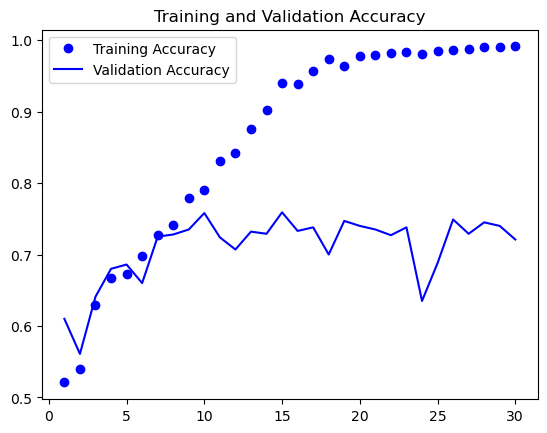

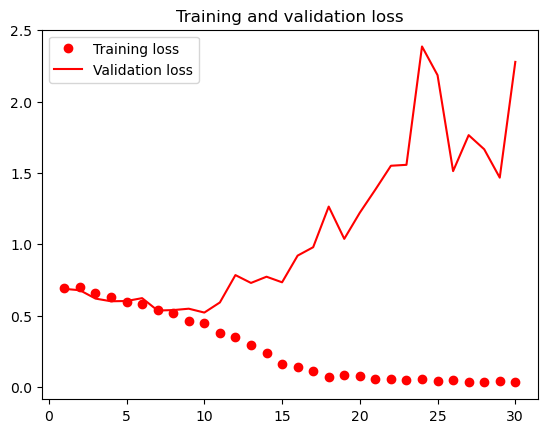

In [19]:
import matplotlib.pyplot as plt

accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training Accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "ro", label="Training loss")
plt.plot(epochs, val_loss, "r", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [20]:
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test Accuracy: {test_acc:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 119ms/step - accuracy: 0.7420 - loss: 2.3061
Test Accuracy: 0.742


In [21]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
    ]
)

In [24]:
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(inputs)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)
model.compile(loss="binary_crossentropy", optimizer="rmsprop", metrics=["accuracy"])

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=r"C:\Users\ISMAIMZ\OneDrive - Hapag-Lloyd AG\Documents\Books\cats_vs_dogs_small\convnet_from_scratch_with_augmentation.keras",
        save_best_only=True,
        monitor="val_loss")
]

history = model.fit(
    train_dataset,
    epochs=100,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 451ms/step - accuracy: 0.4985 - loss: 0.6993 - val_accuracy: 0.5450 - val_loss: 0.6909
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 32s 516ms/step - accuracy: 0.5430 - loss: 0.6885 - val_accuracy: 0.5480 - val_loss: 0.6817
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 43s 684ms/step - accuracy: 0.5970 - loss: 0.6658 - val_accuracy: 0.6230 - val_loss: 0.6613
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 41s 650ms/step - accuracy: 0.6285 - loss: 0.6406 - val_accuracy: 0.5600 - val_loss: 0.8895
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 43s 679ms/step - accuracy: 0.6610 - loss: 0.6104 - val_accuracy: 0.7010 - val_loss: 0.5802
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 44s 696ms/step - accuracy: 0.7030 - loss: 0.5840 - val_accuracy: 0.7030 - val_loss: 0.5723
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 42s 661ms/step - accuracy: 0.7170 - loss: 0.5551 - val_accuracy: 0.6810 - val_loss: 0.6534
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 42s 672ms/step - accuracy: 0.7330 - loss: 0.5363 - 

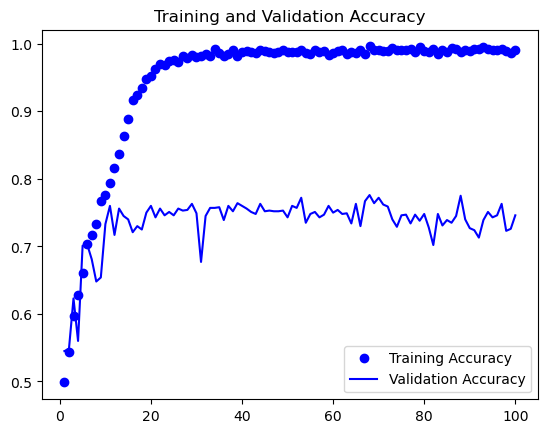

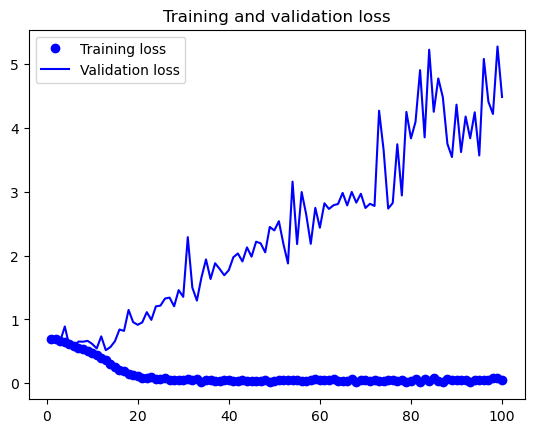

In [25]:
import matplotlib.pyplot as plt

accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training Accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [27]:
test_model = keras.models.load_model(r"C:\Users\ISMAIMZ\OneDrive - Hapag-Lloyd AG\Documents\Books\cats_vs_dogs_small\convnet_from_scratch_with_augmentation.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test Accuracy: {test_acc:.3f}")    

63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 119ms/step - accuracy: 0.7415 - loss: 0.5442
Test Accuracy: 0.742


In [46]:
conv_base = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(180, 180, 3))

In [29]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 180, 180, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 180, 180, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 90, 90, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 90, 90, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 90, 90, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 45, 45, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 45, 45, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 22, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 22, 22, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 11, 11, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 5, 5, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
import numpy as np

def get_features_and_labels(dataset):
    all_features = []
    all_labels = []
    for images, labels in dataset:
        preprocessed_images = keras.applications.vgg16.preprocess_input(images)
        features = conv_base.predict(preprocessed_images)
        all_features.append(features)
        all_labels.append(labels)
    return np.concatenate(all_features), np.concatenate(all_labels)

train_features, train_labels = get_features_and_labels(train_dataset)
val_features, val_labels = get_features_and_labels(validation_dataset)
test_features, test_labels = get_features_and_labels(test_dataset)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 

In [50]:
train_features.shape

(2000, 5, 5, 512)

In [41]:
inputs = keras.Input(shape=(5, 5, 512))
x = layers.Flatten()(inputs)
x = layers.Dense(256)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)

model.compile(loss="binary_crossentropy", optimizer="rmsprop", metrics=["accuracy"])

history = model.fit(
    train_features, train_labels,
    epochs=20,
    validation_data=(val_features, val_labels))

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9315 - loss: 17.3217 - val_accuracy: 0.9740 - val_loss: 4.5463
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9675 - loss: 4.2935 - val_accuracy: 0.9700 - val_loss: 6.0922
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9855 - loss: 2.1313 - val_accuracy: 0.9720 - val_loss: 5.3793
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9900 - loss: 1.6865 - val_accuracy: 0.9800 - val_loss: 5.9832
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9905 - loss: 1.1509 - val_accuracy: 0.9640 - val_loss: 9.1148
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9910 - loss: 1.7108 - val_accuracy: 0.9670 - val_loss: 9.1546
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9960 - loss: 0.9735 - val_accuracy: 0.9790 - val_loss: 6.2618
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9970 - loss: 0.3502 - val_accuracy: 0.9730 - 

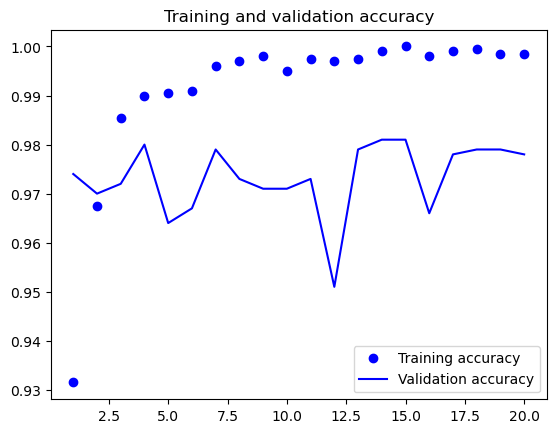

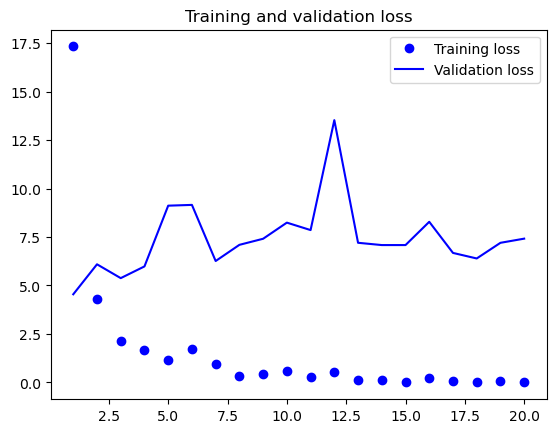

In [42]:
import matplotlib.pyplot as plt

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "bo", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [5]:
from tensorflow import keras
from tensorflow.keras import layers

conv_base = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False)
conv_base.trainable = False

In [6]:
conv_base.trainable = True
print("This is the number of trainable weights " 
"before freezing the conv base:", len(conv_base.trainable_weights))

This is the number of trainable weights before freezing the conv base: 26


In [7]:
conv_base.trainable = False
print("This is the number of trainable weights " 
"after freezing the conv base:", len(conv_base.trainable_weights))

This is the number of trainable weights after freezing the conv base: 0


In [8]:
conv_base = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(180, 180, 3))

In [9]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 180, 180, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 180, 180, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 90, 90, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 90, 90, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 90, 90, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 45, 45, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 45, 45, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 22, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 22, 22, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 11, 11, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 5, 5, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
conv_base.trainable = True
for layer in conv_base.layers[:-4]:
    layer.trainable = False

In [11]:
model = keras.Sequential([
    conv_base,
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])


model.compile(loss="binary_crossentropy",
      optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),
      metrics=["accuracy"])

history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 305s 5s/step - accuracy: 0.6870 - loss: 4.0887 - val_accuracy: 0.8590 - val_loss: 0.7278
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 338s 5s/step - accuracy: 0.8360 - loss: 1.0637 - val_accuracy: 0.8910 - val_loss: 0.4799
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 347s 6s/step - accuracy: 0.9040 - loss: 0.4986 - val_accuracy: 0.9070 - val_loss: 0.4252
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 338s 5s/step - accuracy: 0.9400 - loss: 0.2970 - val_accuracy: 0.9100 - val_loss: 0.4227
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 337s 5s/step - accuracy: 0.9605 - loss: 0.1642 - val_accuracy: 0.9220 - val_loss: 0.3577
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 348s 6s/step - accuracy: 0.9720 - loss: 0.1135 - val_accuracy: 0.9250 - val_loss: 0.3901
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 337s 5s/step - accuracy: 0.9740 - loss: 0.0973 - val_accuracy: 0.9260 - val_loss: 0.3538
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 325s 5s/step - accuracy: 0.9860 - loss: 0.0507 - val_accuracy: 0.9330 - v

In [12]:
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 236s 4s/step - accuracy: 0.9615 - loss: 0.3415
Test accuracy: 0.961


# Lesson - 9 ( Advanced deep learning for computer vision )

In [1]:
import pathlib
import matplotlib.pyplot as plt
from keras.utils import load_img, img_to_array

input_dir = pathlib.Path(r"C:\Users\ISMAIMZ\OneDrive - Hapag-Lloyd AG\Documents\Books\archive\images\images")
target_dir = pathlib.Path(r"C:\Users\ISMAIMZ\OneDrive - Hapag-Lloyd AG\Documents\Books\archive\annotations\trimaps")

input_img_paths = list(input_dir.glob("*.jpg"))
target_paths = list(target_dir.glob("*.png"))

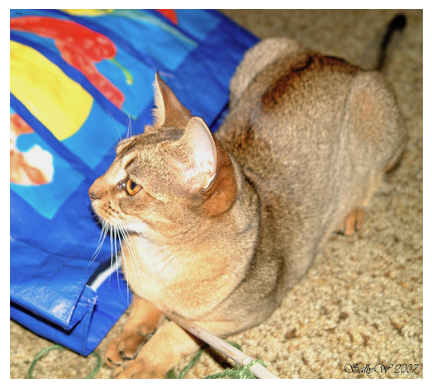

In [2]:
target_dict = {p.stem: p for p in target_paths}

img_path = input_img_paths[9]
mask_path = target_dict[img_path.stem]

plt.axis("off")
plt.imshow(load_img(img_path))

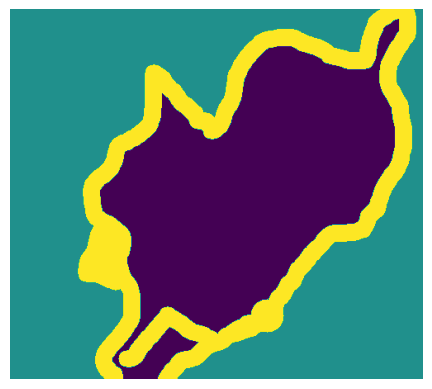

In [3]:
def display_target(target_array):
    normalized_array = (target_array.astype("uint8") - 1) * 127
    plt.axis("off")
    plt.imshow(normalized_array[:, :, 0])

img = img_to_array(load_img(mask_path, color_mode="grayscale"))
display_target(img)

In [4]:
import numpy as np
import random

img_size = (200, 200)

data_pairs = [(img_path, target_dict[img_path.stem]) for img_path in input_img_paths if img_path.stem in target_dict]
random.Random(1337).shuffle(data_pairs)

num_imgs = len(data_pairs)

input_imgs = np.zeros((num_imgs,) + img_size + (3,), dtype="float32")
targets = np.zeros((num_imgs,) + img_size + (1,), dtype="uint8")

def path_to_input_image(path):
    return img_to_array(load_img(path, target_size=img_size))

def path_to_target(path):
    img = img_to_array(
        load_img(path, target_size=img_size, color_mode="grayscale"))
    img = img.astype("uint8") - 1
    return img

for i, (img_path, mask_path) in enumerate(data_pairs):
    input_imgs[i] = path_to_input_image(img_path)
    targets[i] = path_to_target(mask_path)

In [5]:
num_val_samples = 1000
train_input_imgs = input_imgs[:-num_val_samples]
train_targets = targets[:-num_val_samples]
val_input_imgs = input_imgs[-num_val_samples:]
val_targets = targets[-num_val_samples:]

In [6]:
from tensorflow import keras
from tensorflow.keras import layers

def get_model(img_size, num_classes):
    inputs = keras.Input(shape=img_size + (3,))
    x = layers.Rescaling(1./255)(inputs)

    x = layers.Conv2D(64, 3, strides=2, activation="relu", padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.Conv2D(128, 3, strides=2, activation="relu", padding="same")(x)
    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = layers.Conv2D(256, 3, strides=2, activation="relu", padding="same")(x)
    x = layers.Conv2D(256, 3, activation="relu", padding="same")(x)

    x = layers.Conv2DTranspose(256, 3, activation="relu", padding="same")(x)
    x = layers.Conv2DTranspose(256, 3, activation="relu", padding="same", strides=2)(x)
    x = layers.Conv2DTranspose(128, 3, activation="relu", padding="same")(x)
    x = layers.Conv2DTranspose(128, 3, activation="relu", padding="same", strides=2)(x)
    x = layers.Conv2DTranspose(64, 3, activation="relu", padding="same")(x)
    x = layers.Conv2DTranspose(64, 3, activation="relu", padding="same", strides=2)(x)

    outputs = layers.Conv2D(num_classes, 3, activation="softmax", padding="same")(x)
    model = keras.Model(inputs, outputs)
    return model

model = get_model(img_size=img_size, num_classes=3)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 100, 100, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 50, 50, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 25, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 25, 25, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 25, 25, 256)    │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 50, 50, 256)    │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 50, 50, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 100, 100, 128)  │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 100, 100, 64)   │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 200, 200, 64)   │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 200, 200, 3)    │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,880,643 (10.99 MB)

 Trainable params: 2,880,643 (10.99 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(32, 32, 3))
x = layers.Conv2D(32, 3, activation="relu")(inputs)
residual = x
x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
residual = layers.Conv2D(64, 1)(residual)
x = layers.add([x, residual])

In [9]:
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(32, 32, 3))
x = layers.Conv2D(32, 3, activation="relu")(inputs)
residual = x
x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(2, padding="same")(x)
residual = layers.Conv2D(64, 1, strides=2)(residual)
x = layers.add([x, residual])

In [10]:
inputs = keras.Input(shape=(32, 32, 3))
x = layers.Rescaling(1./255)(inputs)

def residual_block(x, filters, pooling=False):
    residual = x
    x = layers.Conv2D(filters, 3, activation="relu", padding="same")(x)
    x = layers.Conv2D(filters, 3, activation="relu", padding="same")(x)
    if pooling:
        x = layers.MaxPooling2D(2, padding="same")(x)
        residual = layers.Conv2D(filters, 1, strides=2)(residual)
    elif filters != residual.shape[-1]:
        residual = layers.Conv2D(filters, 1)(residual)
    x = layers.add([x, residual])
    return x

x = residual_block(x, filters=32, pooling=True)
x = residual_block(x, filters=64, pooling=True)
x = residual_block(x, filters=128, pooling=False)

x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 32, 32, 3) │          0 │ input_layer_3[0]… │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 32, 32,    │        896 │ rescaling_1[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 32, 32,    │      9,248 │ conv2d_13[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 16,    │          0 │ conv2d_14[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 16, 16,    │        128 │ rescaling_1[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 16, 16,    │          0 │ max_pooling2d_1[… │
│                     │ 32)               │            │ conv2d_15[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 16, 16,    │     18,496 │ add_2[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 16, 16,    │     36,928 │ conv2d_16[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 8, 8, 64)  │          0 │ conv2d_17[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 8, 8, 64)  │      2,112 │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 8, 8, 64)  │          0 │ max_pooling2d_2[… │
│                     │                   │            │ conv2d_18[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 8, 8, 128) │     73,856 │ add_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 8, 8, 128) │    147,584 │ conv2d_19[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 8, 8, 128) │      8,320 │ add_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 8, 8, 128) │          0 │ conv2d_20[0][0],  │
│                     │                   │            │ conv2d_21[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ add_4[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │        129 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 297,697 (1.14 MB)

 Trainable params: 297,697 (1.14 MB)

 Non-trainable params: 0 (0.00 B)

In [2]:
from tensorflow import keras

model = keras.models.load_model(r"C:\Users\ISMAIMZ\OneDrive - Hapag-Lloyd AG\Documents\Books\cats_vs_dogs_small\convnet_from_scratch_with_augmentation.keras")
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │        12,545 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,982,084 (7.56 MB)

 Trainable params: 991,041 (3.78 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 991,043 (3.78 MB)

# Lesson - 10 (Deep learning for timeseries)

In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\ISMAIMZ\OneDrive - Hapag-Lloyd AG\Documents\Books\jenna climate\archive\jena_climate_2009_2016.csv")
df

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.30,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.40,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.90,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.20,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.10,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420546,31.12.2016 23:20:00,1000.07,-4.05,269.10,-8.13,73.10,4.52,3.30,1.22,2.06,3.30,1292.98,0.67,1.52,240.0
420547,31.12.2016 23:30:00,999.93,-3.35,269.81,-8.06,69.71,4.77,3.32,1.44,2.07,3.32,1289.44,1.14,1.92,234.3
420548,31.12.2016 23:40:00,999.82,-3.16,270.01,-8.21,67.91,4.84,3.28,1.55,2.05,3.28,1288.39,1.08,2.00,215.2
420549,31.12.2016 23:50:00,999.81,-4.23,268.94,-8.53,71.80,4.46,3.20,1.26,1.99,3.20,1293.56,1.49,2.16,225.8


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420551 entries, 0 to 420550
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Date Time        420551 non-null  object 
 1   p (mbar)         420551 non-null  float64
 2   T (degC)         420551 non-null  float64
 3   Tpot (K)         420551 non-null  float64
 4   Tdew (degC)      420551 non-null  float64
 5   rh (%)           420551 non-null  float64
 6   VPmax (mbar)     420551 non-null  float64
 7   VPact (mbar)     420551 non-null  float64
 8   VPdef (mbar)     420551 non-null  float64
 9   sh (g/kg)        420551 non-null  float64
 10  H2OC (mmol/mol)  420551 non-null  float64
 11  rho (g/m**3)     420551 non-null  float64
 12  wv (m/s)         420551 non-null  float64
 13  max. wv (m/s)    420551 non-null  float64
 14  wd (deg)         420551 non-null  float64
dtypes: float64(14), object(1)
memory usage: 48.1+ MB


In [12]:
print(list(df.columns))
print(len(df))

['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']
420551


In [2]:
temprature = df.iloc[:, 2].values

In [3]:
raw_data = df.iloc[:, 1:].values

In [4]:
print(temprature.shape)
print(raw_data.shape)

(420551,)
(420551, 14)


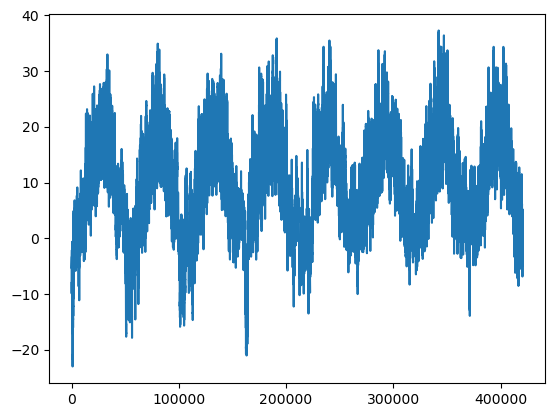

In [16]:
import matplotlib.pyplot as plt

plt.plot(range(len(temprature)), temprature)

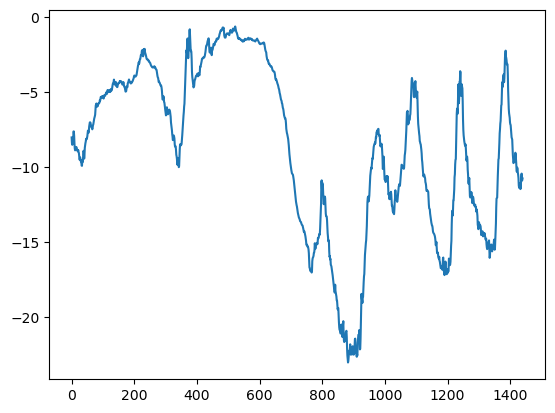

In [17]:
plt.plot(range(1440), temprature[:1440])

In [5]:
num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples

In [6]:
print("num_train_samples:", num_train_samples)
print("num_value_samples:", num_val_samples)
print("num_test_samples:", num_test_samples)

num_train_samples: 210275
num_value_samples: 105137
num_test_samples: 105139


In [7]:
mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

In [9]:
from tensorflow import keras
from tensorflow.keras import layers

sampling_rate = 6
sequence_length = 120 
delay = sampling_rate * (sequence_length + 24 - 1)
batch_size = 256

train_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temprature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples)

val_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temprature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples)

test_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temprature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    end_index=num_train_samples + num_val_samples)

In [10]:
for samples, targets in train_dataset:
    print("samples shape:", samples.shape)
    print("targets shape:", targets.shape)
    break

samples shape: (256, 120, 14)
targets shape: (256,)


In [21]:
import numpy as np

def evaluate_naive_meathod(dataset):
    total_abs_err = 0
    samples_seen = 0
    for samples, targets in dataset:
        preds = samples[:, -1, 1] * std[1] + mean[1]
        total_abs_err += np.sum(np.abs(preds - targets))
        samples_seen += samples.shape[0]
    return total_abs_err / samples_seen

print(f"Validation MAE: {evaluate_naive_meathod(val_dataset):.2f}")
print(f"Test MAE: {evaluate_naive_meathod(test_dataset):.2f}")

Validation MAE: 2.44
Test MAE: 2.61


In [22]:
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Flatten()(inputs)
x = layers.Dense(16, activation="relu")(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset)

print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - loss: 13.1431 - mae: 2.8111 - val_loss: 10.9667 - val_mae: 2.6294
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 9.5940 - mae: 2.4352 - val_loss: 11.9170 - val_mae: 2.7491
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - loss: 8.6916 - mae: 2.3146 - val_loss: 10.4650 - val_mae: 2.5549
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - loss: 8.1582 - mae: 2.2421 - val_loss: 12.2211 - val_mae: 2.7733
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 7.7583 - mae: 2.1920 - val_loss: 10.5071 - val_mae: 2.5495
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - loss: 7.4840 - mae: 2.1528 - val_loss: 13.1955 - val_mae: 2.8849
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - loss: 7.2754 - mae: 2.1230 - val_loss: 11.9716 - val_mae: 2.7221
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - loss: 7.0651 - mae: 2.0936 - val_loss: 12.3464 - val_mae: 2.7682
Epoch 9/10
819/819 ━━━━━━━━━━━━

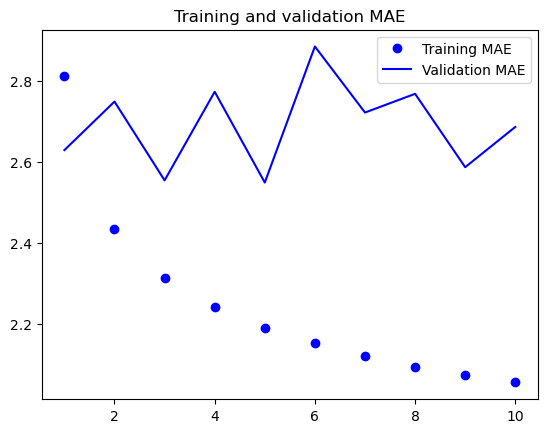

In [23]:
import matplotlib.pyplot as plt

loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

In [26]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Conv1D(8, 24, activation="relu")(inputs)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 12, activation="relu")(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 6, activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1)(x)
model_1 = keras.Model(inputs, outputs)

model_1.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history_1 = model_1.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset)

print(f"Test MAE: {model_1.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - loss: 22.2891 - mae: 3.6908 - val_loss: 18.5284 - val_mae: 3.3825
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - loss: 15.2071 - mae: 3.0984 - val_loss: 15.1018 - val_mae: 3.0593
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 25s 30ms/step - loss: 13.9002 - mae: 2.9598 - val_loss: 14.6392 - val_mae: 3.0163
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 30s 37ms/step - loss: 13.0683 - mae: 2.8664 - val_loss: 14.1753 - val_mae: 2.9677
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 32s 39ms/step - loss: 12.4640 - mae: 2.7991 - val_loss: 15.8968 - val_mae: 3.1516
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 38s 35ms/step - loss: 11.9695 - mae: 2.7390 - val_loss: 14.3908 - val_mae: 2.9799
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 28s 34ms/step - loss: 11.5708 - mae: 2.6917 - val_loss: 16.5225 - val_mae: 3.2265
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 30s 37ms/step - loss: 11.2320 - mae: 2.6522 - val_loss: 15.6195 - val_mae: 3.1233
Epoch 9/10
819/819 ━━━━━

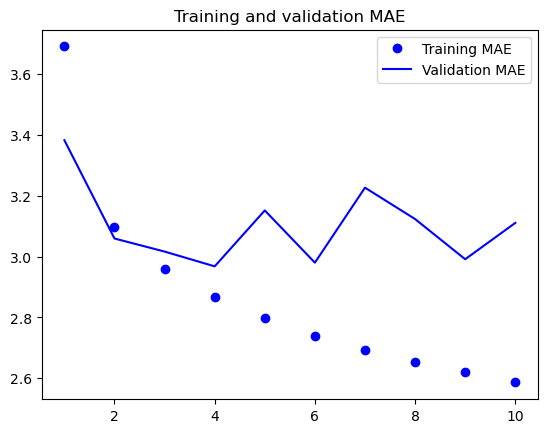

In [27]:
loss = history_1.history["mae"]
val_loss = history_1.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

In [28]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(16)(inputs)
outputs = layers.Dense(1)(x)

model_2 = keras.Model(inputs, outputs)

model_2.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

history_2 = model_2.fit(train_dataset,
                        epochs=10,
                        validation_data=val_dataset)

print(f"Test MAE: {model_2.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 71s 85ms/step - loss: 43.7726 - mae: 4.8143 - val_loss: 12.9839 - val_mae: 2.7489
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 82s 85ms/step - loss: 11.2044 - mae: 2.6041 - val_loss: 9.9767 - val_mae: 2.4543
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 69s 84ms/step - loss: 9.9581 - mae: 2.4633 - val_loss: 10.8186 - val_mae: 2.4914
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 71s 87ms/step - loss: 9.5877 - mae: 2.4128 - val_loss: 10.2070 - val_mae: 2.4447
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 70s 86ms/step - loss: 9.2425 - mae: 2.3684 - val_loss: 10.2419 - val_mae: 2.4357
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 69s 84ms/step - loss: 8.8606 - mae: 2.3237 - val_loss: 9.7228 - val_mae: 2.3946
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 68s 83ms/step - loss: 8.5508 - mae: 2.2833 - val_loss: 9.8170 - val_mae: 2.4208
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 67s 81ms/step - loss: 8.3131 - mae: 2.2522 - val_loss: 9.7819 - val_mae: 2.4315
Epoch 9/10
819/819 ━━━━━━━━━━━━━━━

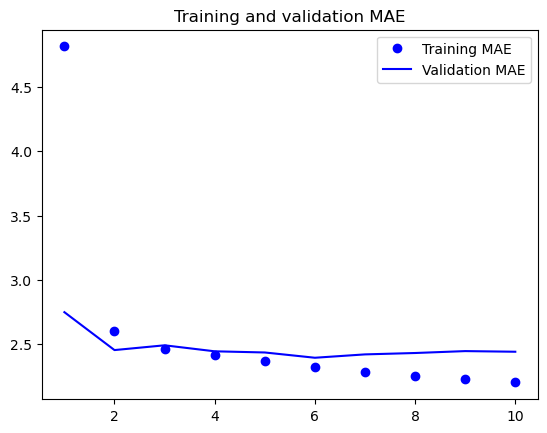

In [29]:
loss = history_2.history["mae"]
val_loss = history_2.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

In [2]:
import numpy as np

timesteps = 100
input_features = 32
output_features = 64
inputs = np.random.random((timesteps, input_features))
state_t = np.zeros((output_features))
W = np.random.random((output_features, input_features))
U = np.random.random((output_features, output_features))
b = np.random.random((output_features,))
successive_outputs = []

for input_t in inputs:
    output_t = np.tanh(np.dot(W, input_t) + np.dot(U, state_t) + b)
    successive_outputs.append(output_t)
    state_t = output_t
final_output_sequence = np.stack(successive_outputs, axis=0)

In [4]:
from tensorflow import keras
from tensorflow.keras import layers

num_features = 14
inputs = keras.Input(shape=(None, num_features))
outputs = layers.SimpleRNN(16)(inputs)

In [5]:
num_features = 14
steps = 120
inputs = keras.Input(shape=(steps, num_features))
outputs = layers.SimpleRNN(16, return_sequences=False)(inputs)
print(outputs.shape)

(None, 16)


In [6]:
num_features = 14
steps = 120
inputs = keras.Input(shape=(steps, num_features))
outputs = layers.SimpleRNN(16, return_sequences=True)(inputs)
print(outputs.shape)

(None, 120, 16)


In [8]:
inputs = keras.Input(shape=(steps, num_features))
x = layers.SimpleRNN(16, return_sequences=True)(inputs)
x = layers.SimpleRNN(16, return_sequences=True)(x)
outputs = layers.SimpleRNN(16)(x)

In [23]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(32, recurrent_dropout=0.25)(inputs)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=50,
                    validation_data=val_dataset)

Epoch 1/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 57ms/step - loss: 27.5746 - mae: 3.8949 - val_loss: 9.4255 - val_mae: 2.3848
Epoch 2/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 56s 68ms/step - loss: 15.0107 - mae: 3.0146 - val_loss: 9.1609 - val_mae: 2.3512
Epoch 3/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 105s 96ms/step - loss: 14.2772 - mae: 2.9337 - val_loss: 8.9928 - val_mae: 2.3280
Epoch 4/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 87s 106ms/step - loss: 13.8722 - mae: 2.8876 - val_loss: 8.9757 - val_mae: 2.3240
Epoch 5/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 88s 108ms/step - loss: 13.3799 - mae: 2.8415 - val_loss: 8.9081 - val_mae: 2.3149
Epoch 6/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 82s 100ms/step - loss: 13.0721 - mae: 2.8094 - val_loss: 8.9708 - val_mae: 2.3227
Epoch 7/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 79s 97ms/step - loss: 12.7465 - mae: 2.7714 - val_loss: 9.0131 - val_mae: 2.3297
Epoch 8/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 81s 99ms/step - loss: 12.4741 - mae: 2.7397 - val_loss: 8.9348 - val_mae: 2.3154
Epoch 9/50
819/819 ━━━━━━━━━

In [25]:
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

1230/1230 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - loss: 7.5096 - mae: 2.1242
Test MAE: 2.12


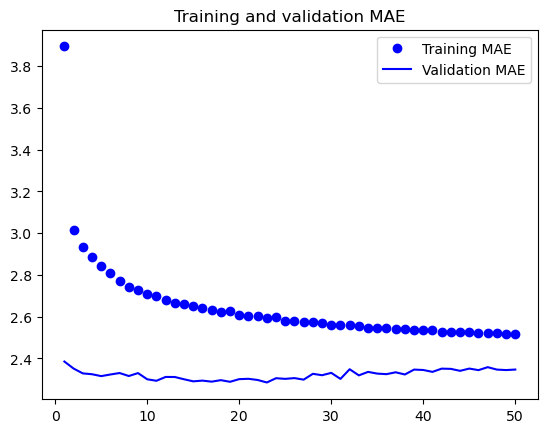

In [24]:
import matplotlib.pyplot as plt

loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

In [15]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.GRU(32, recurrent_dropout=0.5, return_sequences=True)(inputs)
x = layers.GRU(32, recurrent_dropout=0.5)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset)

print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 109s 128ms/step - loss: 25.4784 - mae: 3.7292 - val_loss: 9.5298 - val_mae: 2.3874
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 154s 188ms/step - loss: 14.2551 - mae: 2.9242 - val_loss: 8.9607 - val_mae: 2.3207
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 165s 201ms/step - loss: 13.4224 - mae: 2.8368 - val_loss: 8.8827 - val_mae: 2.3154
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 164s 200ms/step - loss: 13.0419 - mae: 2.7978 - val_loss: 9.0640 - val_mae: 2.3431
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 164s 200ms/step - loss: 12.5101 - mae: 2.7437 - val_loss: 9.0350 - val_mae: 2.3378
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 171s 209ms/step - loss: 12.2154 - mae: 2.7132 - val_loss: 8.5309 - val_mae: 2.2640
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 165s 201ms/step - loss: 11.9008 - mae: 2.6779 - val_loss: 8.4802 - val_mae: 2.2656
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 167s 204ms/step - loss: 11.6453 - mae: 2.6472 - val_loss: 8.8071 - val_mae: 2.3102
Epoch 9/10
819/8

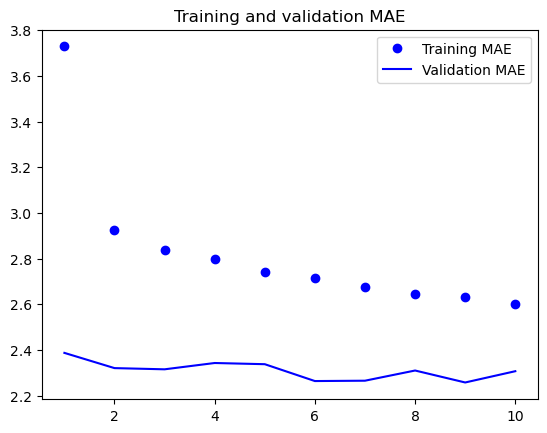

In [16]:
import matplotlib.pyplot as plt

loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

In [17]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Bidirectional(layers.LSTM(16))(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset, epochs=10, validation_data=val_dataset)

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 59s 69ms/step - loss: 25.8249 - mae: 3.6619 - val_loss: 10.5552 - val_mae: 2.5272
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 77s 94ms/step - loss: 9.4755 - mae: 2.3954 - val_loss: 9.5733 - val_mae: 2.4102
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 84s 103ms/step - loss: 8.5299 - mae: 2.2689 - val_loss: 9.9273 - val_mae: 2.4551
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 78s 95ms/step - loss: 8.0208 - mae: 2.2021 - val_loss: 10.0414 - val_mae: 2.4705
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 78s 95ms/step - loss: 7.6201 - mae: 2.1491 - val_loss: 10.1824 - val_mae: 2.4852
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 78s 95ms/step - loss: 7.2708 - mae: 2.0977 - val_loss: 10.7355 - val_mae: 2.5451
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 79s 97ms/step - loss: 6.9994 - mae: 2.0594 - val_loss: 10.7605 - val_mae: 2.5664
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 79s 97ms/step - loss: 6.7171 - mae: 2.0211 - val_loss: 10.5785 - val_mae: 2.5394
Epoch 9/10
819/819 ━━━━━━━━━━━━━

In [18]:
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

1230/1230 ━━━━━━━━━━━━━━━━━━━━ 29s 23ms/step - loss: 7.8738 - mae: 2.1683
Test MAE: 2.17


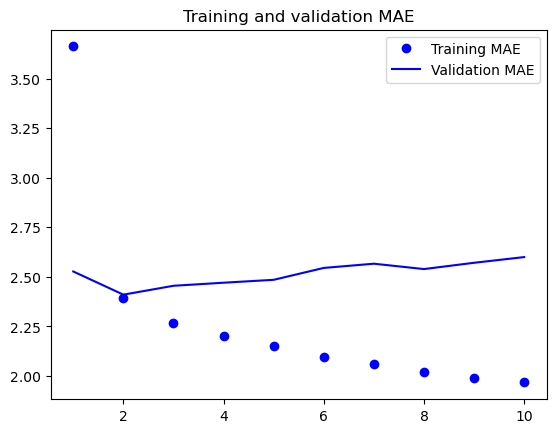

In [19]:
import matplotlib.pyplot as plt

loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

# Lesson - 11 (Deep learning for text)

In [1]:
import string

class Vectorizer:
    def standardize(self, text):
        text = text.lower()
        return "".join(char for char in text if char not in string.punctuation)

    def tokenize(self, text):
        text = self.standardize(text)
        return text.split()

    def make_vocabulary(self, dataset):
        self.vocabulary = {"": 0, "[UNK]": 1}
        for text in dataset:
            text = self.standardize(text)
            tokens = self.tokenize(text)
            for token in tokens:
                if token not in self.vocabulary:
                    self.vocabulary[token] = len(self.vocabulary)
            self.inverse_vocabulary = dict(
                (v, k) for k, v in self.vocabulary.items())

    def encode(self, text):
        text = self.standardize(text)
        tokens = self.tokenize(text)
        return [self.vocabulary.get(token, 1) for token in tokens]

    def docode(self, int_sequence):
        return " ".join(
            self.inverse_vocabulary.get(i, "[UNK]") for i in int_sequence)

vectorizer = Vectorizer()
dataset = [
    "I write, erase, rewrite",
    "Erase again, and then",
    "A Poppy blooms.",
]
vectorizer.make_vocabulary(dataset)

In [3]:
test_sentence = "I write, rewrite, and still rewrite again" 

encd_sentence = vectorizer.encode(test_sentence)
print(encd_sentence)

[2, 3, 5, 7, 1, 5, 6]


In [5]:
decd_sentence = vectorizer.docode(encd_sentence)
print(decd_sentence)

i write rewrite and [UNK] rewrite again


In [6]:
import re
import string
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization

def custom_standardization_fn(string_tensor):
    lowercase_string = tf.strings.lower(string_tensor)
    return tf.strings.regex_replace(
        lowercase_string, f"[{re.escape(string.punctuation)}]", "")

def custom_split_fn(string_tensor):
    return tf.strings.split(string_tensor)

text_vectorization = TextVectorization(
    output_mode = "int",
    standardize = custom_standardization_fn,
    split = custom_split_fn,
)

In [8]:
dataset = [
    "I write, erase, rewrite",
    "Erase again, and then",
    "A Poppy blooms.",
]

text_vectorization.adapt(dataset)

text_vectorization.get_vocabulary()

['',
 '[UNK]',
 'erase',
 'write',
 'then',
 'rewrite',
 'poppy',
 'i',
 'blooms',
 'and',
 'again',
 'a']

In [9]:
vocabulary = text_vectorization.get_vocabulary()
test_sentence = "I write, rewrite, and still rewrite again" 

encd_sentence = text_vectorization(test_sentence)
print(encd_sentence)

tf.Tensor([ 7  3  5  9  1  5 10], shape=(7,), dtype=int64)


In [10]:
inverse_vocab = dict(enumerate(vocabulary))

decd_sentence = " ".join(inverse_vocab[int(i)] for i in encd_sentence)
print(decd_sentence)

i write rewrite and [UNK] rewrite again


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf

df = pd.read_csv(r"C:\Users\ISMAIMZ\OneDrive - Hapag-Lloyd AG\Documents\Books\IMDB movie rewies\archive\IMDB_Movies.csv")

train_df, test_df = train_test_split(df, test_size=0.2, random_state=1337)
train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=1337)

print(len(train_df), len(val_df), len(test_df))

32000 8000 10000


In [15]:
def df_to_dataset(dataframe, batch_size=32):
    dataframe = dataframe.copy()
    labels = dataframe.pop("sentiment")
    ds = tf.data.Dataset.from_tensor_slices((dataframe["review"].values, labels.values))
    ds = ds.shuffle(buffer_size=len(dataframe))
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

batch_size = 32
train_ds = df_to_dataset(train_df, batch_size)
val_ds = df_to_dataset(val_df, batch_size)
test_ds = df_to_dataset(test_df, batch_size)

text_vectorization = tf.keras.layers.TextVectorization(
    max_tokens = 20000,
    output_mode = "multi_hot"
)

text_vectorization.adapt(train_df["review"].values)


train_ds = train_ds.map(lambda x, y: (text_vectorization(x), y)) 
val_ds = val_ds.map(lambda x, y: (text_vectorization(x), y)) 
test_ds = test_ds.map(lambda x, y: (text_vectorization(x), y))

In [9]:
for inputs, targets in train_ds:  
    print("inputs.shape:", inputs.shape)  
    print("inputs.dtype:", inputs.dtype)
    print("targets.shape:", targets.shape)
    print("targets.dtype:", targets.dtype)
    print("inputs[0]:", inputs[0])
    print("targets[0]:", targets[0])
    break

inputs.shape: (32, 20000)
inputs.dtype: <dtype: 'int64'>
targets.shape: (32,)
targets.dtype: <dtype: 'int64'>
inputs[0]: tf.Tensor([1 1 1 ... 0 0 0], shape=(20000,), dtype=int64)
targets[0]: tf.Tensor(0, shape=(), dtype=int64)


In [10]:
from tensorflow import keras
from tensorflow.keras import layers

def get_model(max_tokens=20000, hidden_dim=16):
    inputs = keras.Input(shape=(max_tokens,))
    x = layers.Dense(hidden_dim, activation="relu")(inputs)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
    return model

In [11]:
model = get_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 20000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │       320,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320,033 (1.22 MB)

 Trainable params: 320,033 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.fit(train_ds.cache(),
          validation_data=val_ds.cache(),
          epochs=10)

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.8444 - loss: 0.3782 - val_accuracy: 0.8965 - val_loss: 0.2698
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8993 - loss: 0.2757 - val_accuracy: 0.8931 - val_loss: 0.2818
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9104 - loss: 0.2598 - val_accuracy: 0.8900 - val_loss: 0.2936
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9163 - loss: 0.2518 - val_accuracy: 0.8942 - val_loss: 0.2985
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9175 - loss: 0.2484 - val_accuracy: 0.8900 - val_loss: 0.3046
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9201 - loss: 0.2438 - val_accuracy: 0.8894 - val_loss: 0.3088
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9205 - loss: 0.2432 - val_accuracy: 0.8917 - val_loss: 0.3102
Epoch 8/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9221 - loss: 0.2373 - 

In [13]:
print(f"Test accuracy: {model.evaluate(test_ds)[1]:.3f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8875 - loss: 0.3085
Test accuracy: 0.887


In [18]:
batch_size = 32
train_ds = df_to_dataset(train_df, batch_size)
val_ds = df_to_dataset(val_df, batch_size)
test_ds = df_to_dataset(test_df, batch_size)

text_vectorization = tf.keras.layers.TextVectorization(
    ngrams=2,
    max_tokens = 20000,
    output_mode = "multi_hot"
)

text_vectorization.adapt(train_df["review"].values)


train_ds = train_ds.map(lambda x, y: (text_vectorization(x), y)) 
val_ds = val_ds.map(lambda x, y: (text_vectorization(x), y)) 
test_ds = test_ds.map(lambda x, y: (text_vectorization(x), y))

model.fit(train_ds.cache(),
          validation_data=val_ds.cache(),
          epochs=10)

print(f"Test accuracy: {model.evaluate(test_ds)[1]:.3f}")

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.6490 - loss: 0.9290 - val_accuracy: 0.8001 - val_loss: 0.4820
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7918 - loss: 0.4694 - val_accuracy: 0.8514 - val_loss: 0.3746
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8358 - loss: 0.3962 - val_accuracy: 0.8699 - val_loss: 0.3386
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8572 - loss: 0.3512 - val_accuracy: 0.8792 - val_loss: 0.3210
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8693 - loss: 0.3310 - val_accuracy: 0.8820 - val_loss: 0.3170
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8801 - loss: 0.3104 - val_accuracy: 0.8876 - val_loss: 0.3125
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8878 - loss: 0.2926 - val_accuracy: 0.8849 - val_loss: 0.3127
Epoch 8/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8929 - loss: 0.2846 

In [19]:
batch_size = 32
train_ds = df_to_dataset(train_df, batch_size)
val_ds = df_to_dataset(val_df, batch_size)
test_ds = df_to_dataset(test_df, batch_size)

text_vectorization = tf.keras.layers.TextVectorization(
    ngrams=2,
    max_tokens = 20000,
    output_mode = "tf_idf"
)

text_vectorization.adapt(train_df["review"].values)


train_ds = train_ds.map(lambda x, y: (text_vectorization(x), y)) 
val_ds = val_ds.map(lambda x, y: (text_vectorization(x), y)) 
test_ds = test_ds.map(lambda x, y: (text_vectorization(x), y))

model.fit(train_ds.cache(),
          validation_data=val_ds.cache(),
          epochs=10)

print(f"Test accuracy: {model.evaluate(test_ds)[1]:.3f}")

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.8175 - loss: 4.1693 - val_accuracy: 0.9000 - val_loss: 0.2777
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9100 - loss: 0.2201 - val_accuracy: 0.9000 - val_loss: 0.2883
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9112 - loss: 0.2166 - val_accuracy: 0.9018 - val_loss: 0.2969
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9154 - loss: 0.2108 - val_accuracy: 0.8988 - val_loss: 0.2974
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9178 - loss: 0.2069 - val_accuracy: 0.9026 - val_loss: 0.2999
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9179 - loss: 0.2055 - val_accuracy: 0.9011 - val_loss: 0.3063
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9189 - loss: 0.2035 - val_accuracy: 0.9020 - val_loss: 0.3117
Epoch 8/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9181 - loss: 0.1987

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf

df = pd.read_csv(r"C:\Users\ISMAIMZ\OneDrive - Hapag-Lloyd AG\Documents\Books\IMDB movie rewies\archive\IMDB_Movies.csv")

train_df, test_df = train_test_split(df, test_size=0.2, random_state=1337)
train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=1337)

print(len(train_df), len(val_df), len(test_df))

32000 8000 10000


In [2]:
def df_to_dataset(dataframe, batch_size=32):
    dataframe = dataframe.copy()
    labels = dataframe.pop("sentiment")
    ds = tf.data.Dataset.from_tensor_slices((dataframe["review"].values, labels.values))
    ds = ds.shuffle(buffer_size=len(dataframe))
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

batch_size = 32
train_ds = df_to_dataset(train_df, batch_size)
val_ds = df_to_dataset(val_df, batch_size)
test_ds = df_to_dataset(test_df, batch_size)


max_length = 600
max_tokens = 20000
text_vectorization = tf.keras.layers.TextVectorization(
    max_tokens = max_tokens,
    output_mode = "int",
    output_sequence_length = max_length,
)

text_vectorization.adapt(train_df["review"].astype(str))


train_ds = train_ds.map(lambda x, y: (text_vectorization(x), y)) 
val_ds = val_ds.map(lambda x, y: (text_vectorization(x), y)) 
test_ds = test_ds.map(lambda x, y: (text_vectorization(x), y))

In [5]:
from tensorflow import keras
from tensorflow.keras import layers

max_tokens = 20000 
embedding_dim = 128 
sequence_length = 600

inputs = keras.Input(shape=(sequence_length,), dtype="int64")
x = layers.Embedding(input_dim=max_tokens, output_dim=embedding_dim)(inputs)
x = layers.Bidirectional(layers.LSTM(32, dropout=0.2, recurrent_dropout=0.2))(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 600)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 600, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,601,281 (9.92 MB)

 Trainable params: 2,601,281 (9.92 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.fit(train_ds, validation_data=val_ds, epochs=10)
print(f"Test acc: {model.evaluate(test_ds)[1]:.3f}")

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1158s 1s/step - accuracy: 0.7226 - loss: 0.5509 - val_accuracy: 0.8494 - val_loss: 0.3845
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1282s 1s/step - accuracy: 0.8263 - loss: 0.4222 - val_accuracy: 0.8029 - val_loss: 0.4384
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1292s 1s/step - accuracy: 0.8568 - loss: 0.3672 - val_accuracy: 0.8622 - val_loss: 0.3441
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1341s 1s/step - accuracy: 0.8699 - loss: 0.3316 - val_accuracy: 0.8696 - val_loss: 0.3405
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1361s 1s/step - accuracy: 0.8865 - loss: 0.2942 - val_accuracy: 0.8802 - val_loss: 0.3195
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1381s 1s/step - accuracy: 0.9018 - loss: 0.2656 - val_accuracy: 0.8832 - val_loss: 0.3259
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1452s 1s/step - accuracy: 0.9169 - loss: 0.2316 - val_accuracy: 0.8786 - val_loss: 0.3059
Epoch 8/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1368s 1s/step - accuracy: 0.9287 -

In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

class TransformerEncoder(layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads
        self.attention = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=embed_dim)
        self.dense_proj = keras.Sequential(
            [layers.Dense(dense_dim, activation="relu"),
             layers.Dense(embed_dim),]
        )
        self.layernorm_1 = layers.LayerNormalization()
        self.layernorm_2 = layers.LayerNormalization()

    def call(self, inputs, mask=None):
        if mask is not None:
            mask = mask[:, tf.newaxis, :]
        attention_output = self.attention(
            inputs, inputs, attention_mask=mask)
        proj_input = self.layernorm_1(inputs + attention_output)
        proj_output = self.dense_proj(proj_input)
        return self.layernorm_2(proj_input + proj_output)

    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "dense_dim": self.dense_dim,
        })
        return config

In [8]:
vocab_size = 20000
embed_dim = 256
num_heads = 2
dense_dim = 32

inputs = keras.Input(shape=(None,), dtype="int64")
x = layers.Embedding(vocab_size, embed_dim)(inputs)
x = TransformerEncoder(embed_dim, dense_dim, num_heads)(x)
x = layers.GlobalMaxPooling1D()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, None, 256)      │     5,120,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder             │ (None, None, 256)      │       543,776 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 256)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,664,033 (21.61 MB)

 Trainable params: 5,664,033 (21.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(train_ds, validation_data=val_ds, epochs=10)
print(f"Test acc: {model.evaluate(test_ds)[1]:.3f}")

In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\ISMAIMZ\OneDrive - Hapag-Lloyd AG\Documents\Books\eng-spa\archive\data.csv")

text_pairs = [
    (row["english"], "[start] "  + row["spanish"] +  " [end]")
    for _, row in df.iterrows()
]

print(text_pairs[:5])

[('Go.', '[start] Ve. [end]'), ('Go.', '[start] Vete. [end]'), ('Go.', '[start] Vaya. [end]'), ('Go.', '[start] Váyase. [end]'), ('Hi.', '[start] Hola. [end]')]


In [5]:
import random
print(random.choice(text_pairs))

("Tom didn't ask Mary anything.", '[start] Tom no le preguntó nada a Mary. [end]')


In [3]:
import random

random.shuffle(text_pairs)
num_val_samples = int(0.15 * len(text_pairs))
num_train_samples = len(text_pairs) - 2 * num_val_samples
train_pairs = text_pairs[:num_train_samples]
val_pairs = text_pairs[num_train_samples:num_train_samples + num_val_samples]
test_pairs = text_pairs[num_train_samples + num_val_samples]

In [4]:
import tensorflow as tf
import string
import re

strip_chars = string.punctuation + "¿"
strip_chars = strip_chars.replace("[", "")
strip_chars = strip_chars.replace("]", "")

def custom_standardization(input_string):
    lowercase = tf.strings.lower(input_string)
    return tf.strings.regex_replace(
        lowercase, f"[{re.escape(strip_chars)}]", "")

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

vocab_size = 15000
sequence_length = 20

source_vectorization = layers.TextVectorization(
    max_tokens=vocab_size,
    output_mode="int",
    output_sequence_length=sequence_length,
)

target_vectorization = layers.TextVectorization(
    max_tokens=vocab_size,
    output_mode="int",
    output_sequence_length=sequence_length + 1,
    standardize=custom_standardization,
)

train_english_texts = [pair[0] for pair in train_pairs]
train_spanish_texts = [pair[1] for pair in train_pairs]
source_vectorization.adapt(train_english_texts)
target_vectorization.adapt(train_spanish_texts)

In [7]:
batch_size = 64

def format_dataset(eng, spa):
    eng = source_vectorization(eng)
    spa = target_vectorization(spa)
    return ({
        "english": eng,
        "spanish": spa[:, :-1],
    }, spa[:, 1:])

def make_dataset(pairs):
    eng_texts, spa_texts = zip(*pairs)
    eng_texts = list(eng_texts)
    spa_texts = list(spa_texts)
    dataset = tf.data.Dataset.from_tensor_slices((eng_texts, spa_texts))
    dataset = dataset.batch(batch_size)
    dataset = dataset.map(format_dataset, num_parallel_calls=4)
    return dataset.shuffle(2048).prefetch(16).cache()

train_ds = make_dataset(train_pairs)
val_ds = make_dataset(val_pairs)

In [8]:
for inputs, targets in train_ds.take(1):
    print(f"inputs['english'].shape: {inputs['english'].shape}")
    print(f"inputs['spanish'].shape: {inputs['spanish'].shape}")
    print(f"targets.shape: {targets.shape}")

inputs['english'].shape: (64, 20)
inputs['spanish'].shape: (64, 20)
targets.shape: (64, 20)


In [9]:
inputs = keras.Input(shape=(sequence_length,), dtype="int64")
x = layers.Embedding(input_dim=vocab_size, output_dim=128)(inputs)
x = layers.LSTM(32, return_sequences=True)(x)
outputs = layers.Dense(vocab_size, activation="softmax")(x)
model = keras.Model(inputs, outputs)

In [11]:
embed_dim = 256
latent_dim = 1024

source = keras.Input(shape=(None,), dtype="int64", name="english")
x = layers.Embedding(vocab_size, embed_dim, mask_zero=True)(source)
encoded_source = layers.Bidirectional(
    layers.GRU(latent_dim), merge_mode="sum")(x)

past_target = keras.Input(shape=(None,), dtype="int64", name="spanish")
x = layers.Embedding(vocab_size, embed_dim, mask_zero=True)(past_target)
decoder_gru = layers.GRU(latent_dim, return_sequences=True)
x = decoder_gru(x, initial_state=encoded_source)
x = layers.Dropout(0.5)(x)
target_next_step = layers.Dense(vocab_size, activation="softmax")(x)
seq2seq_rnn = keras.Model([source, past_target], target_next_step)

In [13]:
seq2seq_rnn.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])
seq2seq_rnn.fit(train_ds, epochs=5, validation_data=val_ds)

Epoch 1/5
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 3409s 3s/step - accuracy: 0.3252 - loss: 4.5878 - val_accuracy: 0.3939 - val_loss: 3.8357
Epoch 2/5
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 3359s 3s/step - accuracy: 0.4198 - loss: 3.6862 - val_accuracy: 0.4722 - val_loss: 3.2004
Epoch 3/5
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 3734s 3s/step - accuracy: 0.4742 - loss: 3.1943 - val_accuracy: 0.5180 - val_loss: 2.8472
Epoch 4/5
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 4142s 3s/step - accuracy: 0.5130 - loss: 2.8524 - val_accuracy: 0.5524 - val_loss: 2.6033
Epoch 5/5
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 3915s 3s/step - accuracy: 0.5466 - loss: 2.5824 - val_accuracy: 0.5778 - val_loss: 2.4298


In [14]:
import numpy as np

spa_vocab = target_vectorization.get_vocabulary()
spa_index_lookup = dict(zip(range(len(spa_vocab)), spa_vocab))
max_decoded_sentence_length = 20

def decode_sequence(input_sentence):
    tokenized_input_sentence = source_vectorization([input_sentence])
    decoded_sentence = "[start] "
    for i in range(max_decoded_sentence_length):
        tokenized_target_sentence = target_vectorization([decoded_sentence])
        next_token_predictions = seq2seq_rnn.predict(
            [tokenized_input_sentence, tokenized_target_sentence])
        sampled_token_index = np.argmax(next_token_predictions[0, i, :])
        sampled_token = spa_index_lookup[sampled_token_index]
        decoded_sentence += " " + sampled_token
        if sampled_token == " [end]":
            break
    return decoded_sentence

In [15]:
test_eng_texts = [pair[0] for pair in test_pairs]
for _ in range(20):
    input_sentence = random.choice(test_eng_texts)
    print("-")
    print(input_sentence)
    print(decode_sequence(input_sentence))

-
[
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
[start]  a la gente [end]  [end] [end] [end] [end] [end] [end] [end] [end] [end] [end] [end] [end] [end] [end] [end]
-
H
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━

In [43]:
from keras import ops

class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, input_dim, output_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_embeddings = layers.Embedding(
            input_dim = input_dim, output_dim=output_dim)
        self.position_embeddings = layers.Embedding(
        input_dim=sequence_length, output_dim=output_dim)
        self.sequence_length = sequence_length
        self.input_dim = input_dim
        self.output_dim = output_dim

    def call(self, inputs):
        length = tf.shape(inputs)[-1]
        positions = tf.range(start=0, limit=length, delta=1)
        embedded_tokens = self.token_embeddings(inputs)
        embedded_positions = self.position_embeddings(positions)
        return embedded_tokens + embedded_positions

    def compute_mask(self, inputs, mask=None):
        return ops.not_equal(inputs, 0)

    def get_config(self):
        config = super().get_config()
        config.update({
            "output_dim": self.output_dim,
            "sequence_length": self.sequence_length,
            "input_dim": self.input_dim,
        })
        return config

In [47]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

class TransformerEncoder(layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads
        self.attention = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=embed_dim)
        self.dense_proj = keras.Sequential(
            [layers.Dense(dense_dim, activation="relu"),
             layers.Dense(embed_dim),]
        )
        self.layernorm_1 = layers.LayerNormalization()
        self.layernorm_2 = layers.LayerNormalization()
        self.support_masking = True
        
    def call(self, inputs, mask=None):
        if mask is not None:
            mask = mask[:, tf.newaxis, :]
        attention_output = self.attention(
            inputs, inputs, attention_mask=mask)
        proj_input = self.layernorm_1(inputs + attention_output)
        proj_output = self.dense_proj(proj_input)
        return self.layernorm_2(proj_input + proj_output)

    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "dense_dim": self.dense_dim,
        })
        return config

In [48]:
class TransformerDecoder(layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads
        self.attention_1 = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim)
        self.attention_2 = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim)
        self.dense_proj = keras.Sequential(
            [layers.Dense(dense_dim, activation="relu"),
             layers.Dense(embed_dim),]
        )
        self.layernorm_1 = layers.LayerNormalization()
        self.layernorm_2 = layers.LayerNormalization()
        self.layernorm_3 = layers.LayerNormalization()
        self.supports_masking = True
    
    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "dense_dim": self.dense_dim,
        })
        return config
    
    def get_causal_attention_mask(self, inputs):
        input_shape = tf.shape(inputs)
        batch_size, sequence_length = input_shape[0], input_shape[1]
        i = tf.range(sequence_length)[:, tf.newaxis]
        j = tf.range(sequence_length)
        mask = tf.cast(i >= j, dtype="int32")
        mask = tf.reshape(mask, (1, input_shape[1], input_shape[1]))
        mult = tf.concat(
            [tf.expand_dims(batch_size, -1),
             tf.constant([1, 1], dtype=tf.int32)], axis=0)
        return tf.tile(mask, mult)

    def call(self, inputs, encoder_outputs, mask=None):
        causal_mask = self.get_causal_attention_mask(inputs)
        if mask is not None:
            padding_mask = tf.cast(
                mask[:, tf.newaxis, :], dtype="int32")
            padding_mask = tf.minimum(padding_mask, causal_mask)
        else:
            padding_mask = causal_mask
            
        attention_output_1 = self.attention_1(
            query=inputs,
            value=inputs,
            key=inputs,
            attention_mask=causal_mask)
        attention_output_1 = self.layernorm_1(inputs + attention_output_1)
        attention_output_2 = self.attention_2(
            query=attention_output_1,
            value=encoder_outputs,
            key=encoder_outputs,
            attention_mask=padding_mask,
        )
        attention_output_2 = self.layernorm_2(
            attention_output_1 + attention_output_2)
        proj_output = self.dense_proj(attention_output_2)
        return self.layernorm_3(attention_output_2 + proj_output)

In [49]:
vocab_size = 15000
sequence_length = 20
embed_dim = 256
dense_dim = 2048
num_heads = 8

encoder_inputs = keras.Input(shape=(None,), dtype="int64", name="english")
x = PositionalEmbedding(sequence_length, vocab_size, embed_dim)(encoder_inputs)
encoder_outputs = TransformerEncoder(embed_dim, dense_dim, num_heads)(x)

decoder_inputs = keras.Input(shape=(None,), dtype="int64", name="spanish")
x = PositionalEmbedding(sequence_length, vocab_size, embed_dim)(decoder_inputs)
x = TransformerDecoder(embed_dim, dense_dim, num_heads)(x, encoder_outputs)
x = layers.Dropout(0.5)(x)
decoder_outputs = layers.Dense(vocab_size, activation="softmax")(x)
transformer = keras.Model([encoder_inputs, decoder_inputs], decoder_outputs)

C:\Users\ISMAIMZ\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\layer.py:970: UserWarning: Layer 'transformer_encoder_5' (of type TransformerEncoder) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


In [50]:
transformer.compile(optimizer="rmsprop", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
transformer.fit(train_ds, epochs=1, validation_data=val_ds)

1302/1302 ━━━━━━━━━━━━━━━━━━━━ 2488s 2s/step - accuracy: 0.4421 - loss: 3.7846 - val_accuracy: 0.5329 - val_loss: 2.8915


In [52]:
import numpy as np
spa_vocab = target_vectorization.get_vocabulary()
spa_index_lookup = dict(zip(range(len(spa_vocab)), spa_vocab))
max_decoded_sentence_length = 20

def decode_sequence(input_sentences):
    tokenized_input_sentences = source_vectorization([input_sentences])
    decoded_sentence = "[start]"
    for i in range(max_decoded_sentence_length):
        tokenized_target_sentence = target_vectorization(
            [decoded_sentence])[:, :-1]
        predictions = transformer(
            [tokenized_input_sentences, tokenized_target_sentence])
        sampled_token_index = np.argmax(predictions[0, i, :])
        sampled_token = spa_index_lookup[sampled_token_index]
        decoded_sentence += " " + sampled_token
        if sampled_token == "[end]":
            break
    return decoded_sentence

test_eng_texts = [pair[0] for pair in test_pairs]
for _ in range(20):
    input_sentence = random.choice(test_eng_texts)
    print("-")
    print(input_sentence)
    print(decode_sequence(input_sentence))

-
[
[start] [end]
-
M
[start] los gatos se [UNK] [end]
-
[
[start] [end]
-
M
[start] los gatos se [UNK] [end]
-
M
[start] los gatos se [UNK] [end]
-
[
[start] [end]
-
[
[start] [end]
-
[
[start] [end]
-
M
[start] los gatos se [UNK] [end]
-
M
[start] los gatos se [UNK] [end]
-
M
[start] los gatos se [UNK] [end]
-
M
[start] los gatos se [UNK] [end]
-
[
[start] [end]
-
[
[start] [end]
-
M
[start] los gatos se [UNK] [end]
-
[
[start] [end]
-
[
[start] [end]
-
M
[start] los gatos se [UNK] [end]
-
[
[start] [end]
-
[
[start] [end]


# Lesson - 12 (Generative deep learning)

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf

df = pd.read_csv(r"C:\Users\ISMAIMZ\OneDrive - Hapag-Lloyd AG\Documents\Books\IMDB movie rewies\archive\IMDB_Movies.csv")

train_df, test_df = train_test_split(df, test_size=0.2, random_state=1337)
train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=1337)

print(len(train_df), len(val_df), len(test_df))

32000 8000 10000


In [2]:
import tensorflow as tf


batch_size = 32
sequence_length = 100
vocab_size = 15000


text_vectorization = tf.keras.layers.TextVectorization(
    max_tokens=vocab_size,
    output_mode="int",
    output_sequence_length=sequence_length,
)


text_vectorization.adapt(train_df["review"].astype(str))


def prepare_lm_dataset(text_batch):
    vectorized_sequences = text_vectorization(text_batch)
    x = vectorized_sequences[:, :-1]  
    y = vectorized_sequences[:, 1:]   
    return x, y


train_lm_ds = tf.data.Dataset.from_tensor_slices(train_df["review"].values)
train_lm_ds = train_lm_ds.batch(batch_size).map(prepare_lm_dataset, num_parallel_calls=4)

In [4]:
from keras import ops
from tensorflow.keras import layers

class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, input_dim, output_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_embeddings = layers.Embedding(
            input_dim = input_dim, output_dim=output_dim)
        self.position_embeddings = layers.Embedding(
        input_dim=sequence_length, output_dim=output_dim)
        self.sequence_length = sequence_length
        self.input_dim = input_dim
        self.output_dim = output_dim

    def call(self, inputs):
        length = tf.shape(inputs)[-1]
        positions = tf.range(start=0, limit=length, delta=1)
        embedded_tokens = self.token_embeddings(inputs)
        embedded_positions = self.position_embeddings(positions)
        return embedded_tokens + embedded_positions

    def compute_mask(self, inputs, mask=None):
        return ops.not_equal(inputs, 0)

    def get_config(self):
        config = super().get_config()
        config.update({
            "output_dim": self.output_dim,
            "sequence_length": self.sequence_length,
            "input_dim": self.input_dim,
        })
        return config

In [5]:
class TransformerDecoder(layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads
        self.attention_1 = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim)
        self.attention_2 = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim)
        self.dense_proj = keras.Sequential(
            [layers.Dense(dense_dim, activation="relu"),
             layers.Dense(embed_dim),]
        )
        self.layernorm_1 = layers.LayerNormalization()
        self.layernorm_2 = layers.LayerNormalization()
        self.layernorm_3 = layers.LayerNormalization()
        self.supports_masking = True
    
    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "dense_dim": self.dense_dim,
        })
        return config
    
    def get_causal_attention_mask(self, inputs):
        input_shape = tf.shape(inputs)
        batch_size, sequence_length = input_shape[0], input_shape[1]
        i = tf.range(sequence_length)[:, tf.newaxis]
        j = tf.range(sequence_length)
        mask = tf.cast(i >= j, dtype="int32")
        mask = tf.reshape(mask, (1, input_shape[1], input_shape[1]))
        mult = tf.concat(
            [tf.expand_dims(batch_size, -1),
             tf.constant([1, 1], dtype=tf.int32)], axis=0)
        return tf.tile(mask, mult)

    def call(self, inputs, encoder_outputs, mask=None):
        causal_mask = self.get_causal_attention_mask(inputs)
        if mask is not None:
            padding_mask = tf.cast(
                mask[:, tf.newaxis, :], dtype="int32")
            padding_mask = tf.minimum(padding_mask, causal_mask)
        else:
            padding_mask = causal_mask
            
        attention_output_1 = self.attention_1(
            query=inputs,
            value=inputs,
            key=inputs,
            attention_mask=causal_mask)
        attention_output_1 = self.layernorm_1(inputs + attention_output_1)
        attention_output_2 = self.attention_2(
            query=attention_output_1,
            value=encoder_outputs,
            key=encoder_outputs,
            attention_mask=padding_mask,
        )
        attention_output_2 = self.layernorm_2(
            attention_output_1 + attention_output_2)
        proj_output = self.dense_proj(attention_output_2)
        return self.layernorm_3(attention_output_2 + proj_output)

In [7]:
from tensorflow import keras

embed_dim = 256
latent_dim = 2048
num_heads = 2

inputs = keras.Input(shape=(None,), dtype="int64")
x = PositionalEmbedding(sequence_length, vocab_size, embed_dim)(inputs)
x = TransformerDecoder(embed_dim, latent_dim, num_heads)(x, x)
outputs = layers.Dense(vocab_size, activation="softmax")(x)
model = keras.Model(inputs, outputs)
model.compile(loss="sparse_categorical_crossentropy", optimizer="rmsprop")

In [8]:
import numpy as np

tokens_index = dict(enumerate(text_vectorization.get_vocabulary()))

def sample_next(predictions, temperature=1.0):
    predictions = np.asarray(predictions).astype("float64")
    predictions = np.log(predictions) / temperature
    exp_preds = np.exp(predictions)
    predictions = exp_preds / np.sum(exp_preds)
    probas = np.random.multinomial(1, predictions, 1)
    return np.argmax(probas)

class TextGenerator(keras.callbacks.Callback):
    def __init__(self,
                 prompt,
                 generate_length,
                 model_input_length,
                 temperatures=(1.,),
                 print_freq=1):
        self.prompt = prompt
        self.generate_length = generate_length
        self.model_input_length = model_input_length
        self.temperatures = temperatures
        self.print_freq = print_freq

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.print_freq != 0:
            return
        for temperature in self.temperatures:
            print("== Generating with temperature", temperature)
            sentence = self.prompt
            for i in range(self.generate_length):
                tokenized_sentence = text_vectorization([sentence])
                predictions = self.model(tokenized_sentence)
                next_token = sample_next(predictions[0, i, :])
                sampled_token = tokens_index[next_token]
                sentence += " " + sampled_token
            print(sentence)

prompt = "This movie"
text_gen_callback = TextGenerator(
    prompt,
    generate_length = 50,
    model_input_length = sequence_length,
    temperatures = (0.2, 0.5, 0.7, 1., 1.5))

model.fit(train_lm_ds, epochs=100, callbacks=[text_gen_callback])

Epoch 1/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 6.0671== Generating with temperature 0.2
This movie was might mindblowing to as be it the looks film like or to any 2000 longer a spliced family this the ok intervention we the have acting ever was seen good in in its vegas examine porn and with honestly your looked viewing typical i and [UNK] very remake top
== Generating with temperature 0.5
This movie movie i was never ridiculous failed it to but be it funny would and also my the mum truth br it the confused dvd lets featuring go question for the an acting [UNK] you i their was unique slightly to kristin watch second this 2 movie because is thats clearly
== Generating with temperature 0.7
This movie is when the killer wilderness at was white this people directed rated put it in was the [UNK] second throughout improvement the it writing is of ashamed the of standard the [UNK] [UNK] a last [UNK] be br steamboat i devito have who seen stiller in but [UNK] he movie
== Generat

KeyboardInterrupt: 